# Non-normal dynamics of the AscoliLab connectomic matrix

This notebook is a guided technical analysis of a weighted, signed, directed interaction matrix. Every computational section has four parts:

1. **Question** — what the step is testing.
2. **Terms and equations** — definitions needed to read the result.
3. **Computation** — a bounded table or figure produced by the reproducible pipeline.
4. **What the results mean** — an interpretation cell immediately after the computation.

The notebook distinguishes **asymmetry**, **non-normality**, **reactivity**, **instability**, and **finite-time amplification**. These are related but not interchangeable.


## tl;dr

- The matrix contains 85 labeled nodes and 1,641 nonzero directed effects (22.7% density).
- Its scale-invariant non-normality is very large: commutator index $\eta_C=0.985$ and Henrici index $\eta_H=0.9999$.
- Under spectral-norm normalization and local decay $\gamma=1$, reactivity begins at $g=1.991$, while instability begins at $g=64.074$.
- At the midpoint of that stable-but-reactive interval, the maximum energy gain is $G_\max=177.6$ at $t_*=1.104$.
- The dominant optimal initiator is **CA1 Perforant Path Associated QuadD**; the dominant response receiver is **CA3c Pyramidal**.
- Large effects depend strongly on a small extreme-weight tail. These are mathematical sensitivity results, not demonstrations of biological causation.


## Context & Methods

### Key assumptions

The working convention is

$$A_{ij}=\text{effect of source node }j\text{ on target node }i.$$

Thus columns describe outgoing effects from a source and rows describe incoming effects to a target. The baseline linear model is

$$\dot x=J(g)x,\qquad J(g)=-\gamma I+g\widetilde A,$$

where $x$ is the perturbation state, $I$ is the identity matrix, $g$ is coupling strength, $\gamma=1$ is local decay, and $\widetilde A$ is a normalized form of the empirical matrix. The raw weights have no asserted physical time unit, so raw dynamics are not treated as biologically calibrated.

All calculations use double precision. Random controls use seed `20260901`.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
from IPython.display import display, Image, Markdown

ROOT = Path.cwd()
OUT = ROOT / "analysis_outputs"
TABLES = OUT / "tables"
FIGURES = OUT / "figures"
summary = json.loads((OUT / "summary.json").read_text())

# Set True to regenerate every table and figure from the source CSV.
RUN_FULL_ANALYSIS = False
if RUN_FULL_ANALYSIS:
    from non_normal_analysis import main
    main("mij_matrix.csv", "analysis_outputs")

print("Source:", ROOT / "mij_matrix.csv")
print("Saved analysis:", OUT)
print("Full regeneration enabled:", RUN_FULL_ANALYSIS)


Source: /Users/raniceto/Documents/GitHub/AscoliLab/mij_matrix.csv
Saved analysis: /Users/raniceto/Documents/GitHub/AscoliLab/analysis_outputs
Full regeneration enabled: False


### What the setup output means

The notebook is an executed reader for a deterministic analysis run. With `RUN_FULL_ANALYSIS=False`, it loads the reviewed CSV outputs quickly. Setting the flag to `True` invokes the complete pipeline, including the slower null, lesion, edge, and pseudospectral calculations. No hidden notebook state is required.


## 1. Import and validate the matrix

### Analysis step

This step verifies that the CSV can be treated as a square linear operator and summarizes its entries before any spectral calculation.

### Terms

- **Dimension**: number of rows and columns; a square $n\times n$ matrix maps an $n$-node state back into the same state space.
- **Nonzero entry**: an observed directed interaction. **Density** is the fraction of all $n^2$ entries that are nonzero.
- **Positive/negative entry**: an excitatory-like or inhibitory-like signed effect in the supplied matrix; the sign alone does not establish biological mechanism.
- **Diagonal entry**: $A_{ii}$, a self-effect.
- **NaN/infinity**: invalid non-finite numerical values.
- **All-zero row/column**: a target with no incoming effects or a source with no outgoing effects.
- **Quantile**: a distribution cutoff; for example, the 0.99 quantile exceeds 99% of the observed nonzero weights.


,metric,value
0,n_rows,85
1,n_columns,85
2,nonzero_count,1641
3,nonzero_fraction,0.2271280276816609
4,positive_count,734
5,negative_count,907
6,zero_count,5584
7,minimum_weight,-4691.989954689168
8,maximum_weight,1227402.8954207087
9,nonzero_mean,7326.1467732547635


,quantile,nonzero_weight
0,0.00,-4.691990e+03
1,0.01,-1.153388e+03
2,0.05,-4.032172e+02
3,0.25,-3.341134e+01
4,0.50,-7.862956e-01
5,0.75,5.381001e+02
6,0.95,2.138805e+04
7,0.99,1.590955e+05
8,1.00,1.227403e+06


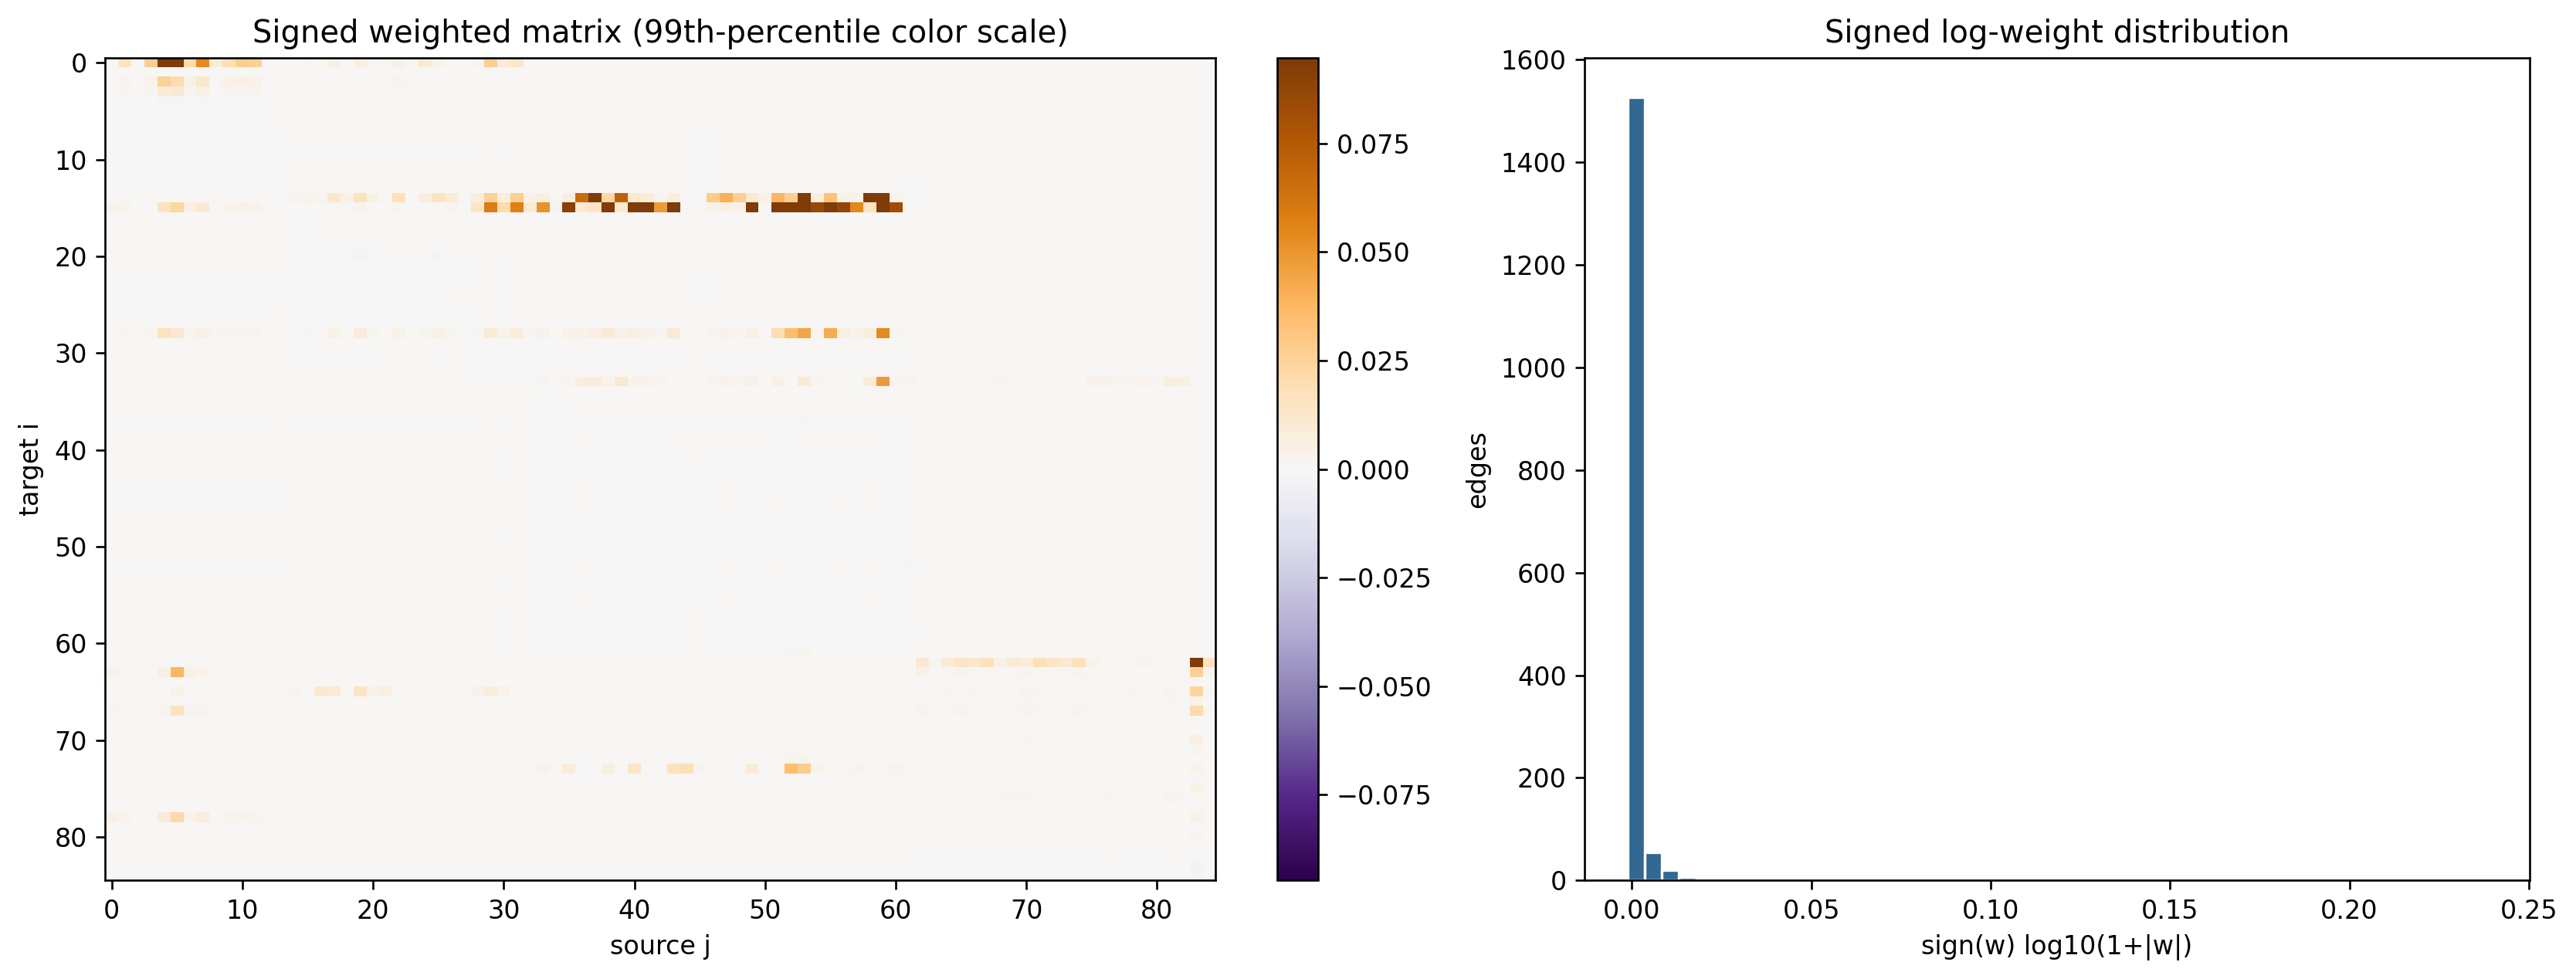

In [2]:
description = pd.read_csv(TABLES / "matrix_descriptive_statistics.csv")
weight_quantiles = pd.read_csv(TABLES / "nonzero_weight_quantiles.csv")
display(description)
display(weight_quantiles)
display(Image(filename=str(FIGURES / "figure01_matrix_and_weights.png")))


### What the validation results mean

The input is a valid 85×85 operator with 1,641 nonzero entries and 22.7% density. It contains 734 positive and 907 negative entries. All values are finite, and there are 0 all-zero rows and 0 all-zero columns, so no node is completely disconnected in the incoming or outgoing direction.

Weights span -4,692.0 to 1,227,402.9. The heat map and signed-log histogram show a highly concentrated, heavy-tailed scale. This motivates normalization and explicit extreme-weight robustness checks; it also means unscaled magnitudes should not be read as biological rates.


## 2. Node strengths and weight concentration

### Analysis step

This step asks which nodes send or receive the largest total interaction weight and whether a small set of nodes or edges dominates the network.

### Terms under $A_{ij}:j\to i$

- **Absolute in-strength** of node $i$: $s_i^{in}=\sum_j|A_{ij}|$; total magnitude arriving at target $i$.
- **Absolute out-strength** of node $j$: $s_j^{out}=\sum_i|A_{ij}|$; total magnitude sent by source $j$.
- **Signed strength**: the algebraic sum retaining cancellation between positive and negative weights.
- **Positive/negative strength**: sums computed separately from positive or negative entries.
- **Degree**: number of nonzero incoming or outgoing edges, ignoring their magnitudes.
- **Weight share**: a node or edge's absolute weight divided by the total absolute weight.
- **Cumulative share**: total share accounted for by the largest entries up to a given rank.


In [3]:
node_strengths = pd.read_csv(TABLES / "node_strengths.csv")
dominant_nodes = pd.read_csv(TABLES / "weight_concentration_nodes.csv")
dominant_edges = pd.read_csv(TABLES / "weight_concentration_edges.csv")
display(dominant_nodes[["node", "absolute_out_strength", "out_weight_share", "absolute_in_strength", "in_weight_share"]].head(12))
display(dominant_edges[["source", "target", "weight", "weight_share", "cumulative_weight_share"]].head(12))


,node,absolute_out_strength,out_weight_share,absolute_in_strength,in_weight_share
0,CA1 Trilaminar,1.569025e+06,0.127766,3085.957793,0.000251
1,CA1 Perforant Path Associated QuadD,1.294472e+06,0.105410,89.903999,0.000007
2,CA1 Perforant Path Associated,9.446877e+05,0.076926,3684.485225,0.000300
3,CA1 R Receiving Apical Targeting,6.521693e+05,0.053106,971.559849,0.000079
4,MEC LIII Superficial Multipolar Interneuron,5.843372e+05,0.047583,6502.103610,0.000529
5,CA1 OR LM,4.652053e+05,0.037882,562.994569,0.000046
6,DG Axo Axonic,4.408370e+05,0.035898,28.972258,0.000002
7,CA1 Basket,4.314537e+05,0.035133,3832.388269,0.000312
8,CA1 Basket CCK+,4.146373e+05,0.033764,8311.926644,0.000677
9,CA1 LMR,4.072545e+05,0.033163,455.566150,0.000037


,source,target,weight,weight_share,cumulative_weight_share
0,CA1 Trilaminar,CA3 Pyramidal,1.227403e+06,0.099948,0.099948
1,CA1 Perforant Path Associated QuadD,CA3c Pyramidal,9.460521e+05,0.077038,0.176986
2,CA1 Perforant Path Associated,CA3c Pyramidal,7.737279e+05,0.063005,0.239991
3,CA1 R Receiving Apical Targeting,CA3c Pyramidal,5.248584e+05,0.042739,0.282730
4,MEC LIII Superficial Multipolar Interneuron,EC LI II Multipolar Pyramidal,4.081471e+05,0.033236,0.315966
5,CA1 OR LM,CA3c Pyramidal,3.571523e+05,0.029083,0.345049
6,CA1 Basket,CA3c Pyramidal,3.525306e+05,0.028707,0.373756
7,CA1 Basket CCK+,CA3c Pyramidal,3.490040e+05,0.028420,0.402175
8,CA1 LMR,CA3c Pyramidal,3.430433e+05,0.027934,0.430109
9,CA1 Oriens Alveus,CA3c Pyramidal,2.710002e+05,0.022068,0.452177


### What the strength results mean

Outgoing magnitude is concentrated: the five strongest source nodes account for 41.1% of total absolute weight. The five largest individual edges account for 31.6%; the single largest edge, **CA1 Trilaminar → CA3 Pyramidal**, carries 10.0% by itself.

This concentration helps explain why clipping or removing a small extreme-weight tail changes later gain estimates sharply. A high out-strength identifies a large sender by weight, but it is not automatically the optimal perturbation initiator because optimal amplification depends on coordinated paths and singular vectors, not one-node totals alone.


## 3. Raw and normalized matrices

### Analysis step

This step separates structural shape from arbitrary global scale by multiplying the matrix by scalar normalization factors.

### Terms

- **Eigenvalue** $\lambda$: a scalar satisfying $Av=\lambda v$ for a nonzero eigenvector $v$.
- **Spectral radius** $\rho(A)=\max_i|\lambda_i|$: largest eigenvalue magnitude.
- **Spectral norm** $\|A\|_2=\sigma_{max}(A)$: largest singular value; the largest one-step Euclidean amplification by $A$.
- **Maximum absolute row sum** $\|A\|_\infty=\max_i\sum_j|A_{ij}|$: largest total absolute input to any target row.
- **Normalization**: division by one of these scales. Scalar normalization changes numerical coupling thresholds but does not change scale-invariant asymmetry or non-normality indices.


In [4]:
normalization_metrics = pd.read_csv(TABLES / "non_normality_metrics.csv")
normalization_thresholds = pd.read_csv(TABLES / "stability_reactivity_thresholds.csv")
display(normalization_metrics[["matrix", "spectral_norm", "spectral_radius", "spectral_abscissa", "numerical_abscissa", "commutator_index", "henrici_index"]])
display(normalization_thresholds)


,matrix,spectral_norm,spectral_radius,spectral_abscissa,numerical_abscissa,commutator_index,henrici_index
0,raw,1.679573e+06,26213.130121,26213.130121,843782.537615,0.985366,0.999876
1,spectral_radius,6.407374e+01,1.000000,1.000000,32.189309,0.985366,0.999876
2,spectral_norm,1.000000e+00,0.015607,0.015607,0.502379,0.985366,0.999876
3,max_row_sum,2.974365e-01,0.004642,0.004642,0.149426,0.985366,0.999876


,normalization,alpha_A,omega_A,g_react,g_stab,reactive_to_stable_ratio,stable_reactive_width
0,raw,26213.130121,843782.537615,0.000001,0.000038,0.031066,0.000037
1,spectral_radius,1.000000,32.189309,0.031066,1.000000,0.031066,0.968934
2,spectral_norm,0.015607,0.502379,1.990529,64.073739,0.031066,62.083210
3,max_row_sum,0.004642,0.149426,6.692282,215.419919,0.031066,208.727638


### What the normalization results mean

The raw, spectral-radius, spectral-norm, and row-sum matrices have identical asymmetry, commutator, and normalized Henrici indices because each differs only by a scalar. Their reported coupling thresholds change inversely with that scalar. For example, spectral-norm normalization gives $g_{react}=1.991$ and $g_{stab}=64.074$, whereas spectral-radius normalization gives thresholds on a different numerical scale.

Therefore the defensible conclusions are about the *existence and relative width* of the stable-reactive interval and gain at a stated fraction of a stability threshold—not the raw numerical value of $g$ unless biological units are supplied.


## 4. Asymmetry and non-normality

### Analysis step

This step determines whether directionality merely makes $A\ne A^T$ or also makes its eigenmodes non-orthogonal enough to support strong transient interactions.

### Terms and equations

$$S=\frac{A+A^T}{2},\qquad K=\frac{A-A^T}{2},\qquad A=S+K.$$

- **Symmetric component** $S$: reciprocal component; $S=S^T$.
- **Skew-symmetric component** $K$: purely directional component; $K=-K^T$.
- **Asymmetry index** $\|A-A^T\|_F/\|A\|_F$: directional mismatch measured with the Frobenius norm $\|A\|_F=\sqrt{\sum_{ij}A_{ij}^2}$.
- **Normal matrix**: $AA^T=A^TA$. A matrix can be asymmetric yet normal.
- **Commutator** $C=AA^T-A^TA$: zero exactly for a real normal matrix.
- **Normalized commutator index** $\eta_C=\|C\|_F/\|A\|_F^2$: scale-invariant commutator magnitude.
- **Henrici departure** $d_H=\sqrt{\|A\|_F^2-\sum_i|\lambda_i|^2}$; $\eta_H=d_H/\|A\|_F$ is its normalized form.
- **Eigenvector condition number** $\kappa(V)=\|V\|\|V^{-1}\|$: sensitivity of an eigenvector decomposition $A=V\Lambda V^{-1}$. Large values indicate non-orthogonal or numerically sensitive eigenvectors; an infinite value indicates defectiveness.


In [5]:
non_normality = pd.read_csv(TABLES / "non_normality_metrics.csv")
display(non_normality)


,matrix,frobenius_norm,spectral_norm,spectral_radius,spectral_abscissa,numerical_abscissa,reactivity_gap,non_normal_reactivity_ratio,asymmetry_index,commutator_index,henrici_departure,henrici_index,eigenvector_condition,diagonalization_warning
0,raw,2.129669e+06,1.679573e+06,26213.130121,26213.130121,843782.537615,817569.407494,32.189309,1.414095,0.985366,2.129405e+06,0.999876,123278.462420,no
1,spectral_radius,8.124435e+01,6.407374e+01,1.000000,1.000000,32.189309,31.189309,32.189309,1.414095,0.985366,8.123429e+01,0.999876,123278.462420,no
2,spectral_norm,1.267982e+00,1.000000e+00,0.015607,0.015607,0.502379,0.486772,32.189309,1.414095,0.985366,1.267825e+00,0.999876,123278.462420,no
3,max_row_sum,3.771441e-01,2.974365e-01,0.004642,0.004642,0.149426,0.144784,32.189309,1.414095,0.985366,3.770974e-01,0.999876,123278.462418,no


### What the non-normality results mean

The empirical matrix has asymmetry index 1.414, but the stronger conclusion comes from $\eta_C=0.985$ and $\eta_H=0.9999$: it is far from normal, not merely directed. The eigenvector condition number is approximately 123,278, showing substantial non-orthogonality and numerical sensitivity, though the decomposition is not flagged as effectively defective by the pipeline's conservative threshold.

High non-normality makes transient amplification possible, but does not by itself prove reactivity or instability. Those require the dynamical matrix $J(g)$ and are tested next.


## 5. Spectral and numerical abscissae

### Analysis step

This step contrasts long-time eigenvalue behavior with the largest possible instantaneous change in perturbation energy.

### Terms

- **Spectral abscissa** $\alpha(A)=\max_i\operatorname{Re}\lambda_i(A)$: largest real part among eigenvalues. For $\dot x=Jx$, $\alpha(J)<0$ means asymptotic linear stability.
- **Numerical abscissa** $\omega(A)=\lambda_{max}((A+A^T)/2)$: maximum instantaneous growth rate of the Euclidean norm.
- **Reactivity gap** $\Delta_{react}=\omega-\alpha$: how much instantaneous growth exceeds the eigenvalue-based rate.
- **Non-normal reactivity ratio** $\omega/\alpha$: a scale-free comparison when $\alpha\ne0$; it is not meaningful when the denominator is zero or changes sign.
- **Stable** means $\alpha(J)<0$; **reactive** means $\omega(J)>0$. A system can be both stable and reactive.


,matrix,spectral_abscissa,numerical_abscissa,reactivity_gap,non_normal_reactivity_ratio
0,raw,26213.130121,843782.537615,817569.407494,32.189309
1,spectral_radius,1.000000,32.189309,31.189309,32.189309
2,spectral_norm,0.015607,0.502379,0.486772,32.189309
3,max_row_sum,0.004642,0.149426,0.144784,32.189309


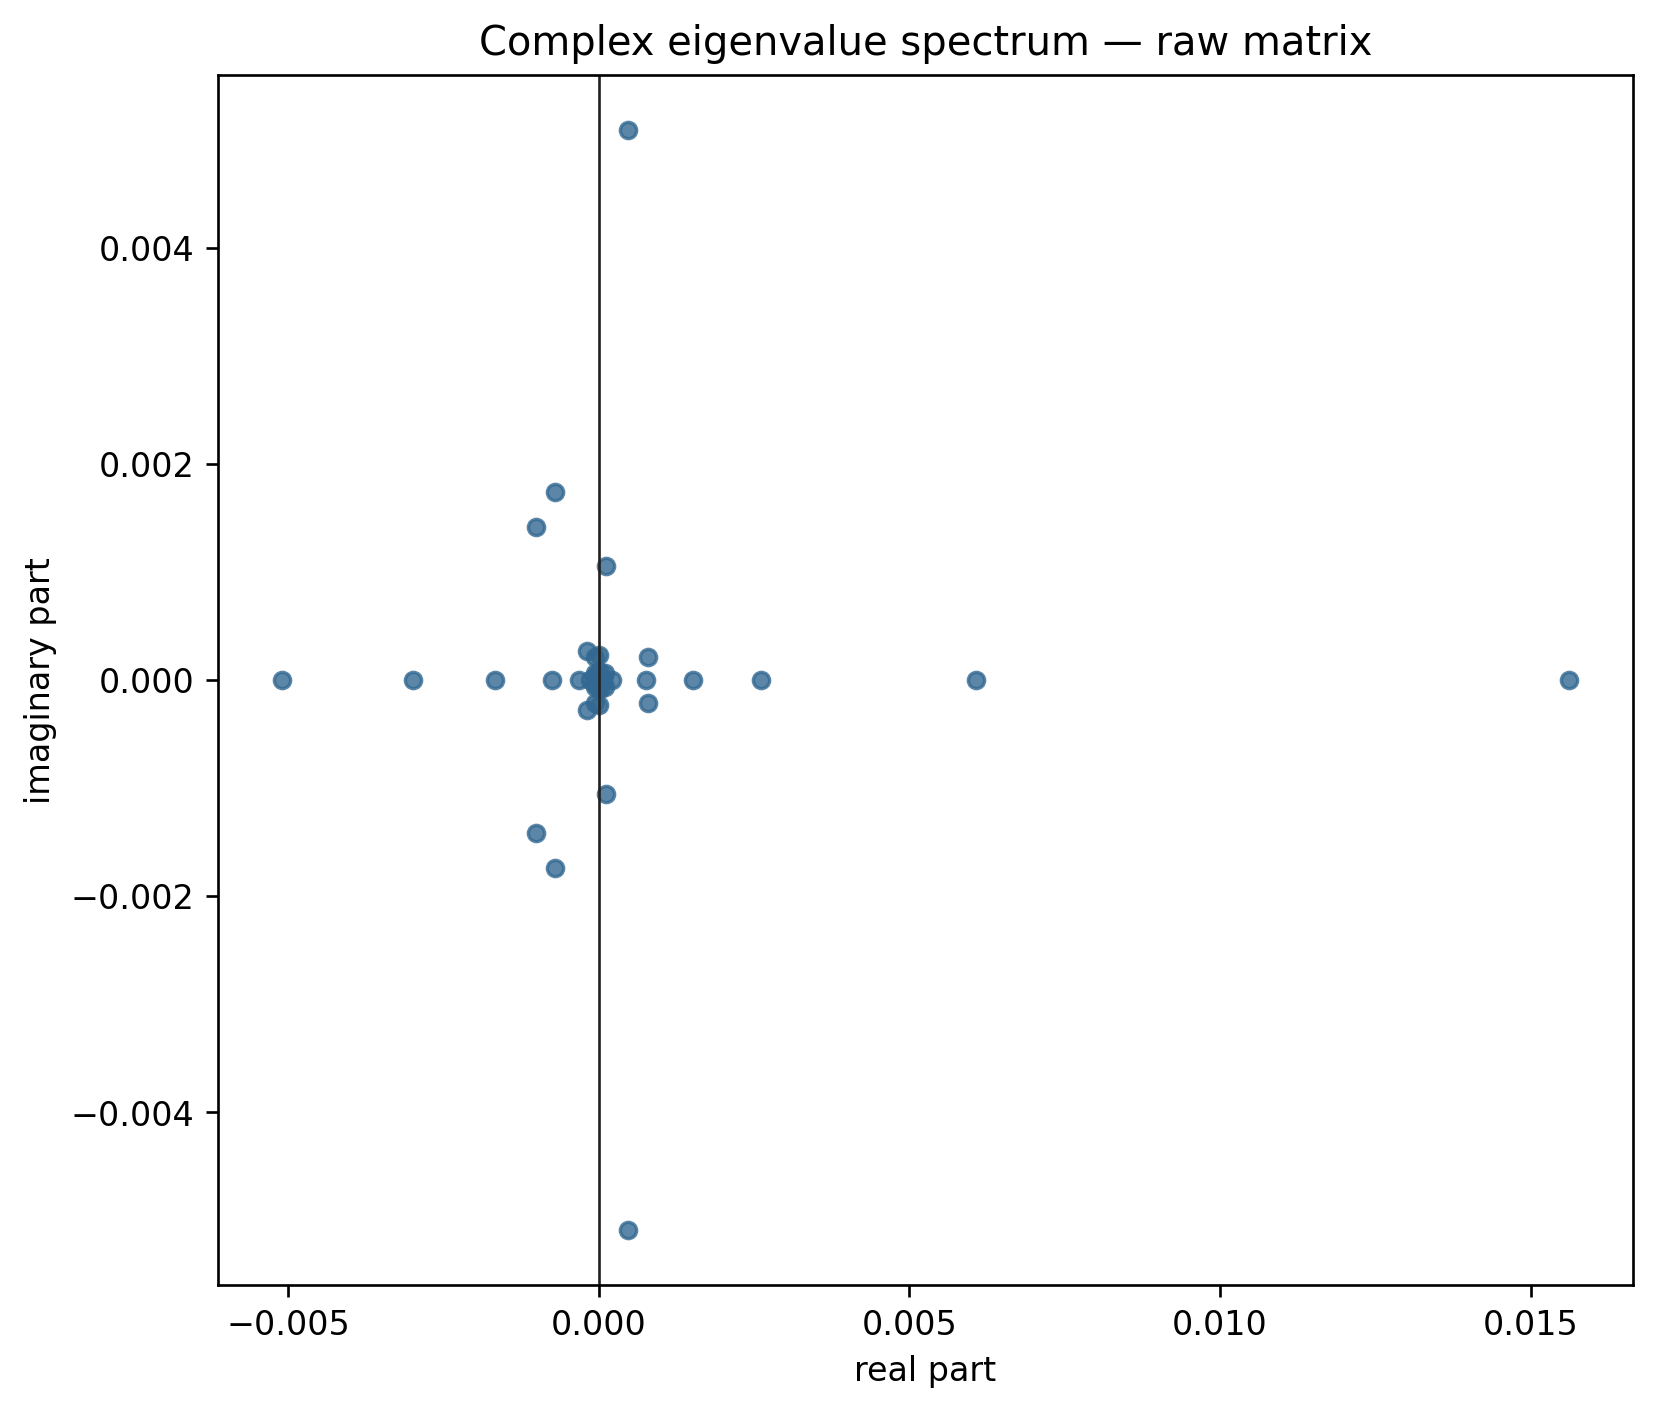

In [6]:
abscissa_table = pd.read_csv(TABLES / "non_normality_metrics.csv")
display(abscissa_table[["matrix", "spectral_abscissa", "numerical_abscissa", "reactivity_gap", "non_normal_reactivity_ratio"]])
display(Image(filename=str(FIGURES / "figure02_eigenvalue_spectrum.png")))


### What the abscissa results mean

For every scalar normalization, $\omega/\alpha=32.2$. In spectral-norm units, $\alpha(A)=0.01561$ while $\omega(A)=0.502$. The numerical abscissa is therefore much larger than the spectral abscissa.

This gap predicts a regime where every eigenmode of $J$ decays eventually but some carefully oriented perturbations initially grow. It would be incorrect to call that regime unstable; instability begins only when $\alpha(J)$ crosses zero.


## 6. Coupling phase diagram and thresholds

### Analysis step

This step embeds the normalized matrix in $J(g)=-I+g\widetilde A$ and varies coupling $g$.

### Terms

- **Local decay** $-I$: in the absence of coupling, every state component decays with nondimensional time constant 1.
- **Coupling** $g$: scalar multiplier controlling the strength of network interaction relative to local decay.
- **Reactivity threshold** $g_{react}=1/\omega(\widetilde A)$ when $\omega>0$: where $\omega(J)$ first becomes zero.
- **Stability threshold** $g_{stab}=1/\alpha(\widetilde A)$ when $\alpha>0$: where $\alpha(J)$ first becomes zero.
- **Stable/non-reactive region**: $\alpha(J)<0$ and $\omega(J)\le0$.
- **Stable/reactive region**: $\alpha(J)<0$ and $\omega(J)>0$.
- **Unstable region**: $\alpha(J)>0$.


,normalization,alpha_A,omega_A,g_react,g_stab,reactive_to_stable_ratio,stable_reactive_width
0,raw,26213.130121,843782.537615,0.000001,0.000038,0.031066,0.000037
1,spectral_radius,1.000000,32.189309,0.031066,1.000000,0.031066,0.968934
2,spectral_norm,0.015607,0.502379,1.990529,64.073739,0.031066,62.083210
3,max_row_sum,0.004642,0.149426,6.692282,215.419919,0.031066,208.727638


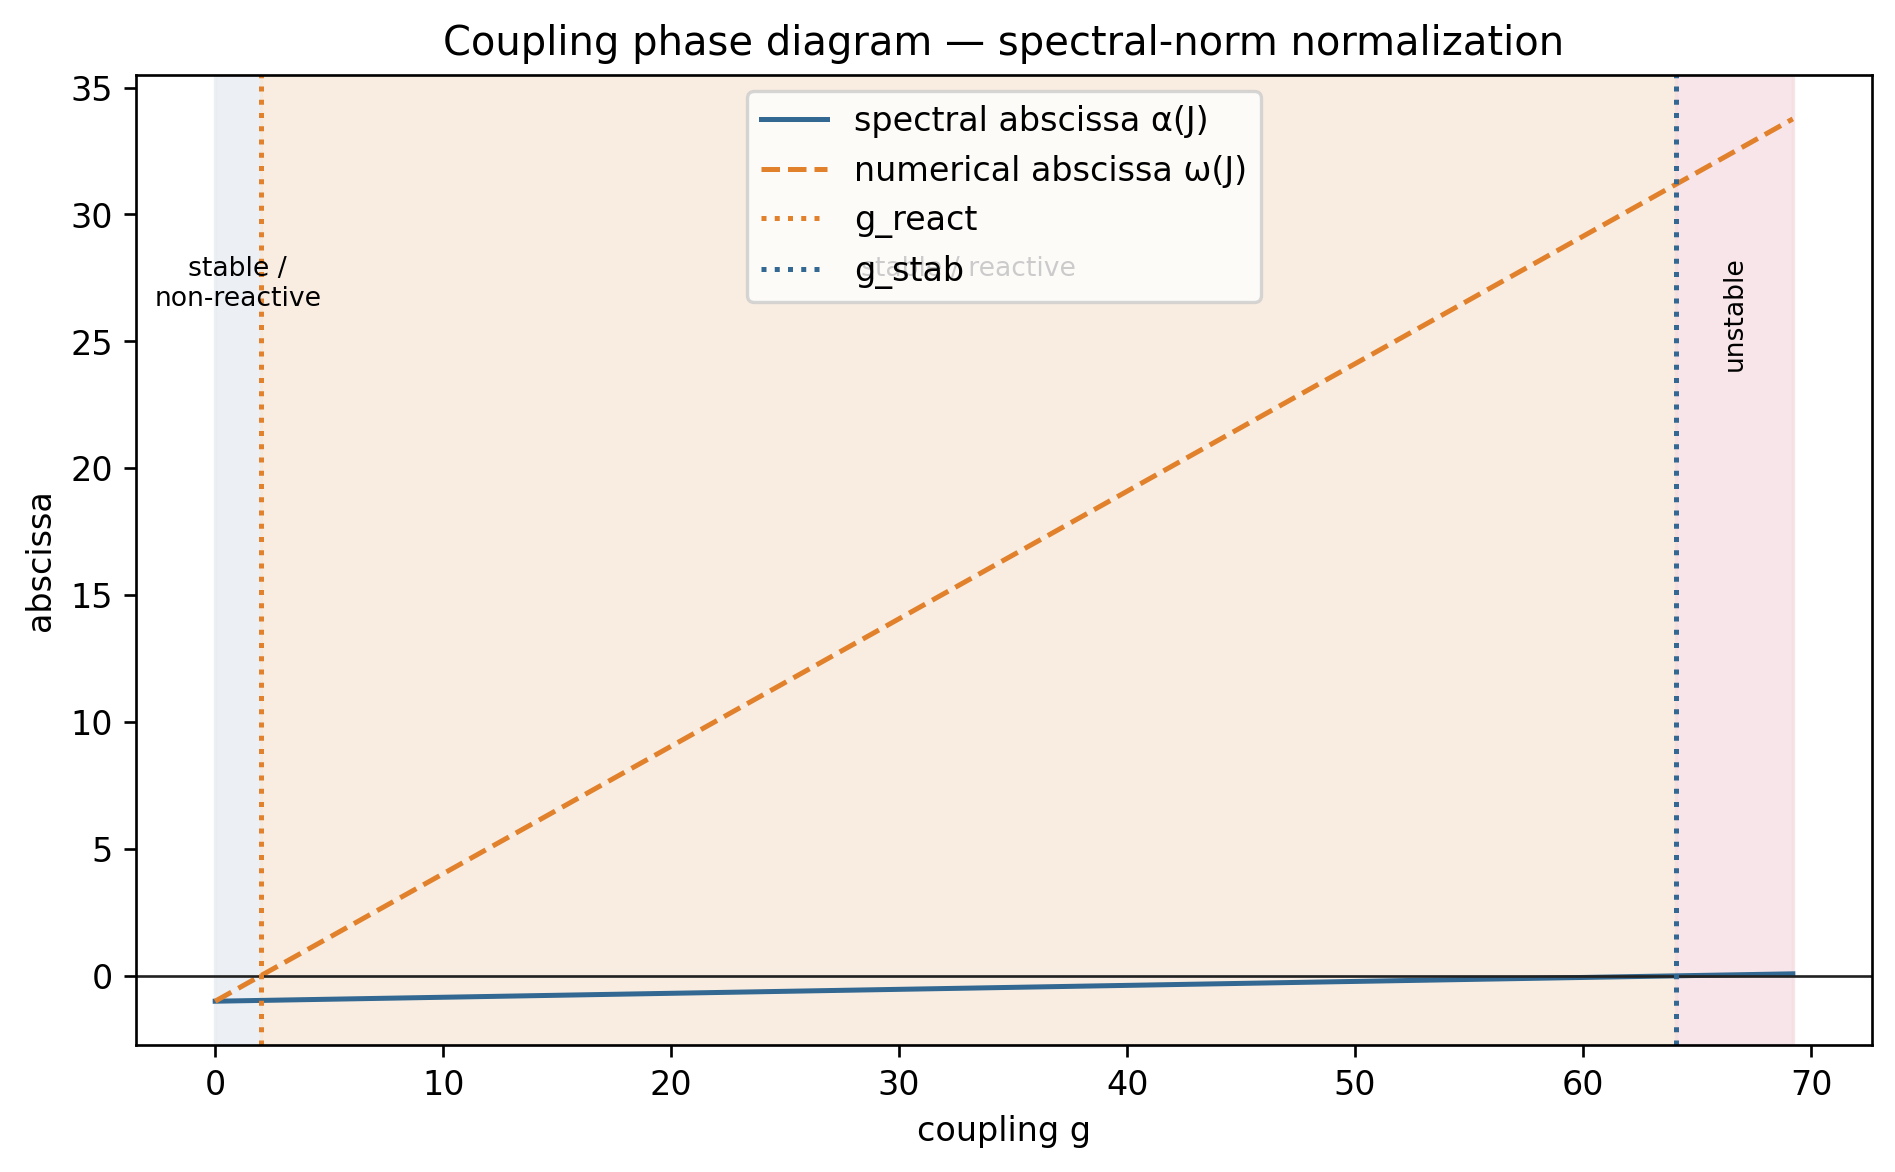

In [7]:
phase = pd.read_csv(TABLES / "coupling_phase.csv")
thresholds = pd.read_csv(TABLES / "stability_reactivity_thresholds.csv")
display(thresholds)
display(Image(filename=str(FIGURES / "figure03_coupling_phase.png")))


### What the phase diagram means

Under spectral-norm normalization, $g_{react}=1.991$ and $g_{stab}=64.074$. Reactivity begins at only 3.1% of the stability threshold, leaving a stable-reactive width of 62.083 coupling units.

The shaded middle region is the core non-normal phenomenon: perturbations can grow temporarily even though $\alpha(J)<0$ guarantees eventual decay. The broad interval is preserved under scalar normalization even though its numerical endpoints change.


## 7. Finite-time transient amplification

### Analysis step

This step computes how much a perturbation can grow over a finite time, rather than inferring behavior only from eigenvalues.

### Terms

- **Propagator** $P(t)=e^{Jt}$: matrix exponential mapping the initial state $x(0)$ to $x(t)$.
- **Singular value** $\sigma_{max}(P)$: maximum norm amplification over all unit-length initial conditions.
- **Energy gain** $G(t;g)=\|e^{Jt}\|_2^2=\sigma_{max}^2(e^{Jt})$: ratio of squared Euclidean response norm to squared initial norm.
- **Maximum gain** $G_{max}(g)=\max_{t\ge0}G(t;g)$.
- **Time to peak** $t_*(g)=\arg\max_tG(t;g)$.
- **Adaptive horizon**: the time window is chosen from the inverse decay rate so slow stable modes are not prematurely truncated.
- **Coarse scan plus refinement**: a time grid locates a candidate maximum, then bounded scalar optimization refines $t_*$.


,coupling_label,g,Gmax,t_star
0,below_reactivity,1.492896,1.000000,0.000000
1,near_reactivity,1.970623,1.000000,0.000000
2,stable_reactive,33.032134,177.644920,1.103699
3,near_stability,60.870052,735.899027,1.246411


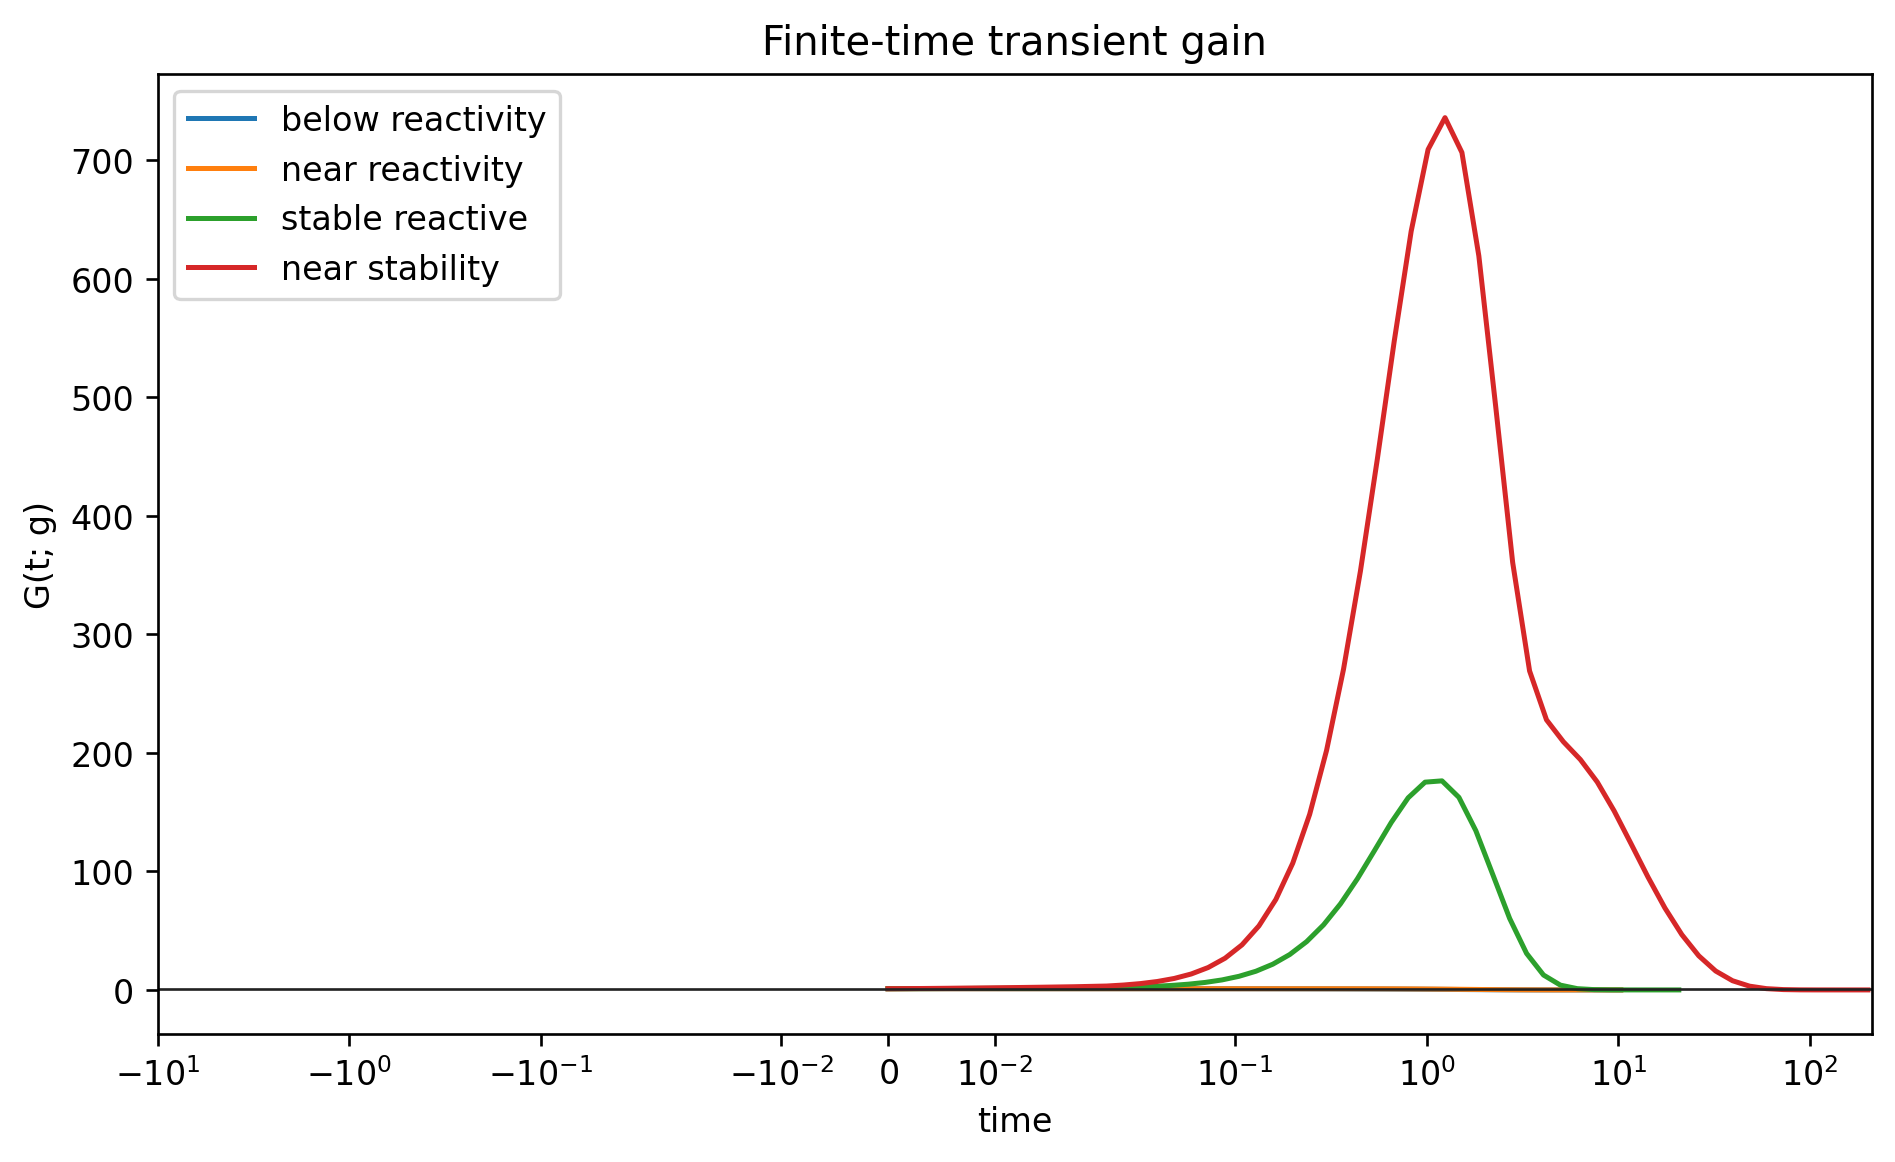

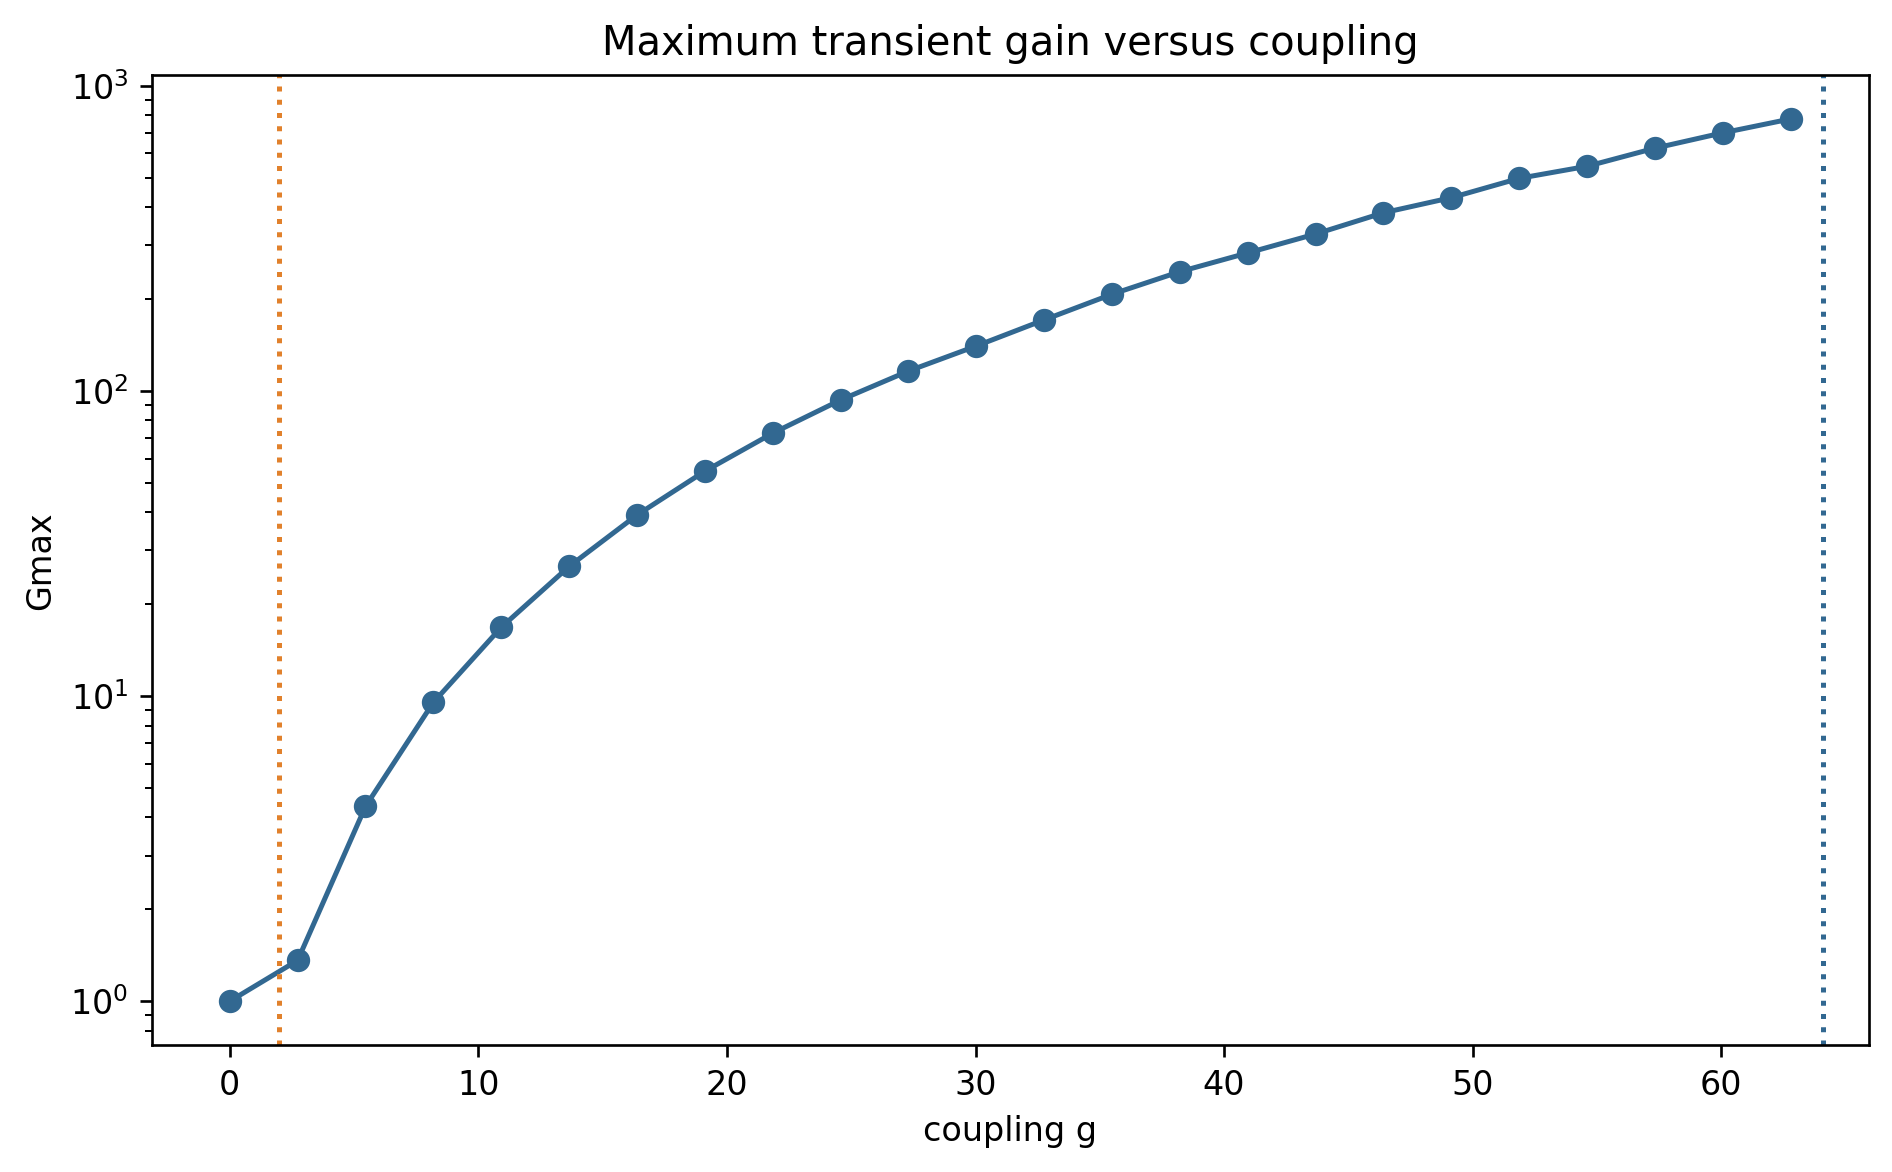

In [8]:
selected_gains = pd.read_csv(TABLES / "selected_coupling_gains.csv")
gain_by_coupling = pd.read_csv(TABLES / "maximum_gain_vs_coupling.csv")
display(selected_gains)
display(Image(filename=str(FIGURES / "figure04_transient_gain_curves.png")))
display(Image(filename=str(FIGURES / "figure05_max_gain_vs_coupling.png")))


### What the transient-gain results mean

Below and immediately before the reactivity threshold, the maximum is $G_{max}=1$ at $t=0$: every later state is smaller. At the midpoint of the stable-reactive interval, $G_{max}=177.6$ at $t_*=1.104$. Near 95% of the stability threshold, gain rises to 735.9.

These are squared-norm or “energy” gains. A gain of 177.6 corresponds to an amplitude gain of $\sqrt{G_{max}}\approx13.3$. The gain is transient: the system remains asymptotically stable at the selected couplings and eventually decays.


## 8. Optimal perturbation and optimal response

### Analysis step

At the peak time, this step uses the singular value decomposition

$$e^{Jt_*}=U\Sigma V^T$$

to identify the coordinated initial pattern that produces maximum amplification and the corresponding response pattern.

### Terms

- **SVD**: factorization into orthonormal left singular vectors $U$, nonnegative singular values $\Sigma$, and orthonormal right singular vectors $V$.
- **Leading right singular vector** $v_1$: unit initial perturbation producing the maximum gain.
- **Leading left singular vector** $u_1$: direction of the maximally amplified response at $t_*$.
- **Initiator score** $|v_{1,i}|$: magnitude of node $i$ in the optimal initial pattern.
- **Receiver score** $|u_{1,i}|$: magnitude of node $i$ in the optimal response pattern.
- Signs of singular vectors are globally arbitrary; rankings therefore use absolute values.


,node,abs_v1,v1
0,CA1 Perforant Path Associated QuadD,0.530130,-0.530130
1,CA1 Trilaminar,0.516984,-0.516984
2,CA1 Perforant Path Associated,0.394212,-0.394212
3,CA1 R Receiving Apical Targeting,0.281861,-0.281861
4,CA1 OR LM,0.199161,-0.199161
5,CA1 Basket,0.180575,-0.180575
6,CA1 Basket CCK+,0.172647,-0.172647
7,CA1 LMR,0.167488,-0.167488
8,CA1 Oriens Alveus,0.138894,-0.138894
9,CA1 Bistratified,0.098116,-0.098116


,node,abs_u1,u1
0,CA3c Pyramidal,0.826999,-0.826999
1,CA3 Pyramidal,0.545875,-0.545875
2,CA2 Pyramidal,0.112593,-0.112593
3,EC LIII Pyramidal Stellate,0.035548,-0.035548
4,CA1 Pyramidal,0.034999,-0.034999
5,DG Granule,0.031815,-0.031815
6,MEC LII Stellate,0.029820,-0.029820
7,EC LI II Multipolar Pyramidal,0.017436,-0.017436
8,CA1 Perforant Path Associated QuadD,0.013179,-0.013179
9,CA1 Trilaminar,0.012454,-0.012454


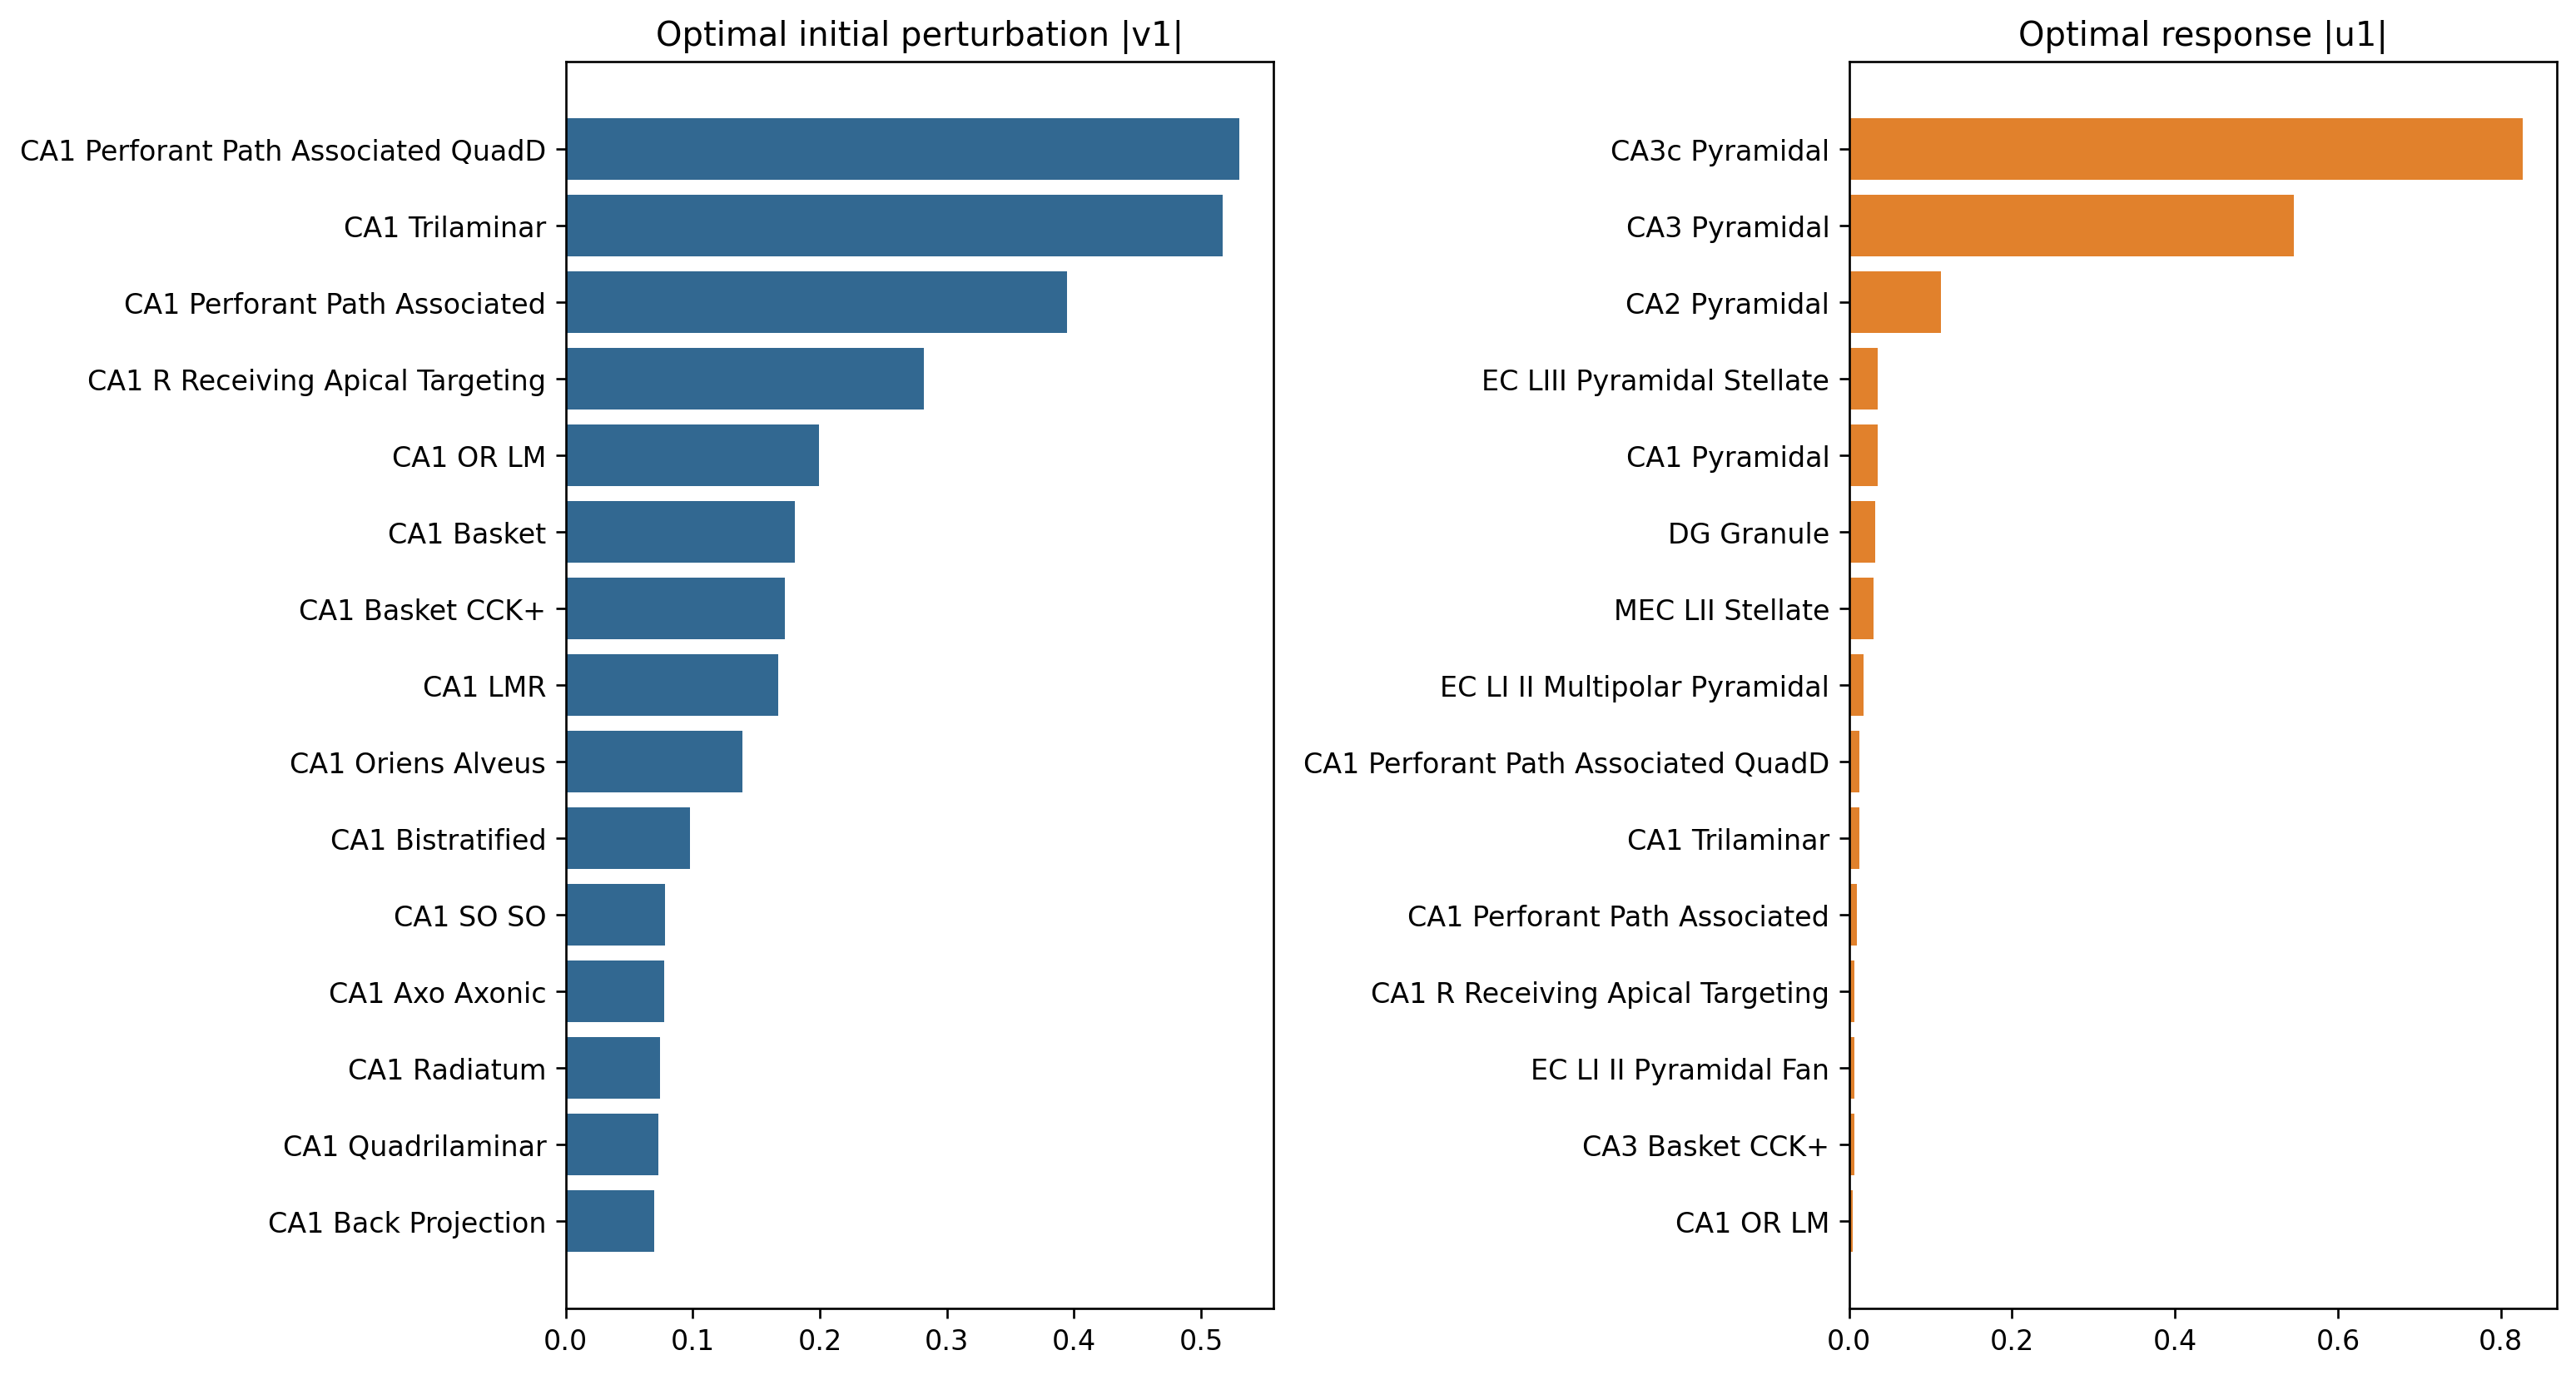

In [9]:
initiators = pd.read_csv(TABLES / "optimal_perturbation_nodes.csv")
receivers = pd.read_csv(TABLES / "optimal_response_nodes.csv")
display(initiators.head(15))
display(receivers.head(15))
display(Image(filename=str(FIGURES / "figure06_optimal_vectors.png")))


### What the optimal-vector results mean

**CA1 Perforant Path Associated QuadD** has the largest initiator magnitude ($|v_1|=0.530$), closely followed by **CA1 Trilaminar**. The amplified response is dominated by **CA3c Pyramidal** ($|u_1|=0.827$) and **CA3 Pyramidal**.

Initiator and receiver rankings differ sharply. This is expected in a directed non-normal system: the best input pattern and the output pattern it produces occupy different node combinations. These vectors describe a coordinated multi-node perturbation, not the effect of activating one node alone.


## 9. Single-node perturbability, susceptibility, and integrated response

### Analysis step

This step constrains the initial condition to one node at a time, $x(0)=e_i$, and separately asks which nodes receive large downstream responses.

### Terms

- **Basis vector** $e_i$: a vector with 1 at node $i$ and 0 elsewhere.
- **Single-node peak gain** $G_i=\max_t\|e^{Jt}e_i\|_2^2$: largest total response energy caused by a unit perturbation at node $i$.
- **Time to peak**: time at which $G_i$ is largest on the adaptive grid.
- **Integrated energy** $R_i=\int_0^\infty\|e^{Jt}e_i\|_2^2dt$: total response accumulated over all time.
- **Observability Gramian** $Q$: solution of $J^TQ+QJ=-I$; $R_i=Q_{ii}$ for stable $J$.
- **Perturbability**: how strongly a node can initiate a network-wide response.
- **Susceptibility**: how strongly a node receives responses across perturbation sources.
- Peak and integrated rankings need not agree because one favors height and the other favors duration.


,node,single_node_peak_gain,time_to_peak,integrated_energy,final_grid_energy,perturbability_rank
0,CA1 Trilaminar,93.269365,1.016351,189.552234,1.964954e-07,1
1,CA1 Perforant Path Associated QuadD,55.005710,1.016351,110.049519,6.660585e-08,2
2,CA1 Perforant Path Associated,34.044722,1.016351,66.978758,4.170826e-08,3
3,CA1 R Receiving Apical Targeting,16.674955,1.016351,33.661092,1.352749e-08,4
4,MEC LIII Superficial Multipolar Interneuron,15.026201,1.213296,39.879410,3.673033e-07,5
5,CA1 OR LM,7.978526,1.016351,16.317832,6.481373e-09,6
6,CA1 Basket,7.021350,1.016351,13.796624,4.540666e-09,7
7,CA1 Basket CCK+,6.764156,1.016351,13.235516,5.536648e-09,8
8,CA1 LMR,6.471741,1.016351,12.595700,6.175924e-09,9
9,CA1 Oriens Alveus,4.343457,1.016351,8.788966,3.904998e-09,10


,node,max_received_amplitude,sum_max_received_amplitude,susceptibility_rank
0,CA3c Pyramidal,7.093433,45.740042,1
1,CA3 Pyramidal,9.394930,25.895047,2
2,EC LI II Multipolar Pyramidal,3.771309,10.445550,3
3,DG Granule,1.631105,8.889583,4
4,CA2 Pyramidal,1.000000,7.232340,5
5,MEC LII Stellate,1.000000,4.429826,6
6,EC LI II Pyramidal Fan,1.000000,4.340567,7
7,CA1 Pyramidal,1.000000,3.172585,8
8,EC LIII Pyramidal Stellate,1.000000,3.018128,9
9,MEC LV Pyramidal,1.000000,2.929186,10


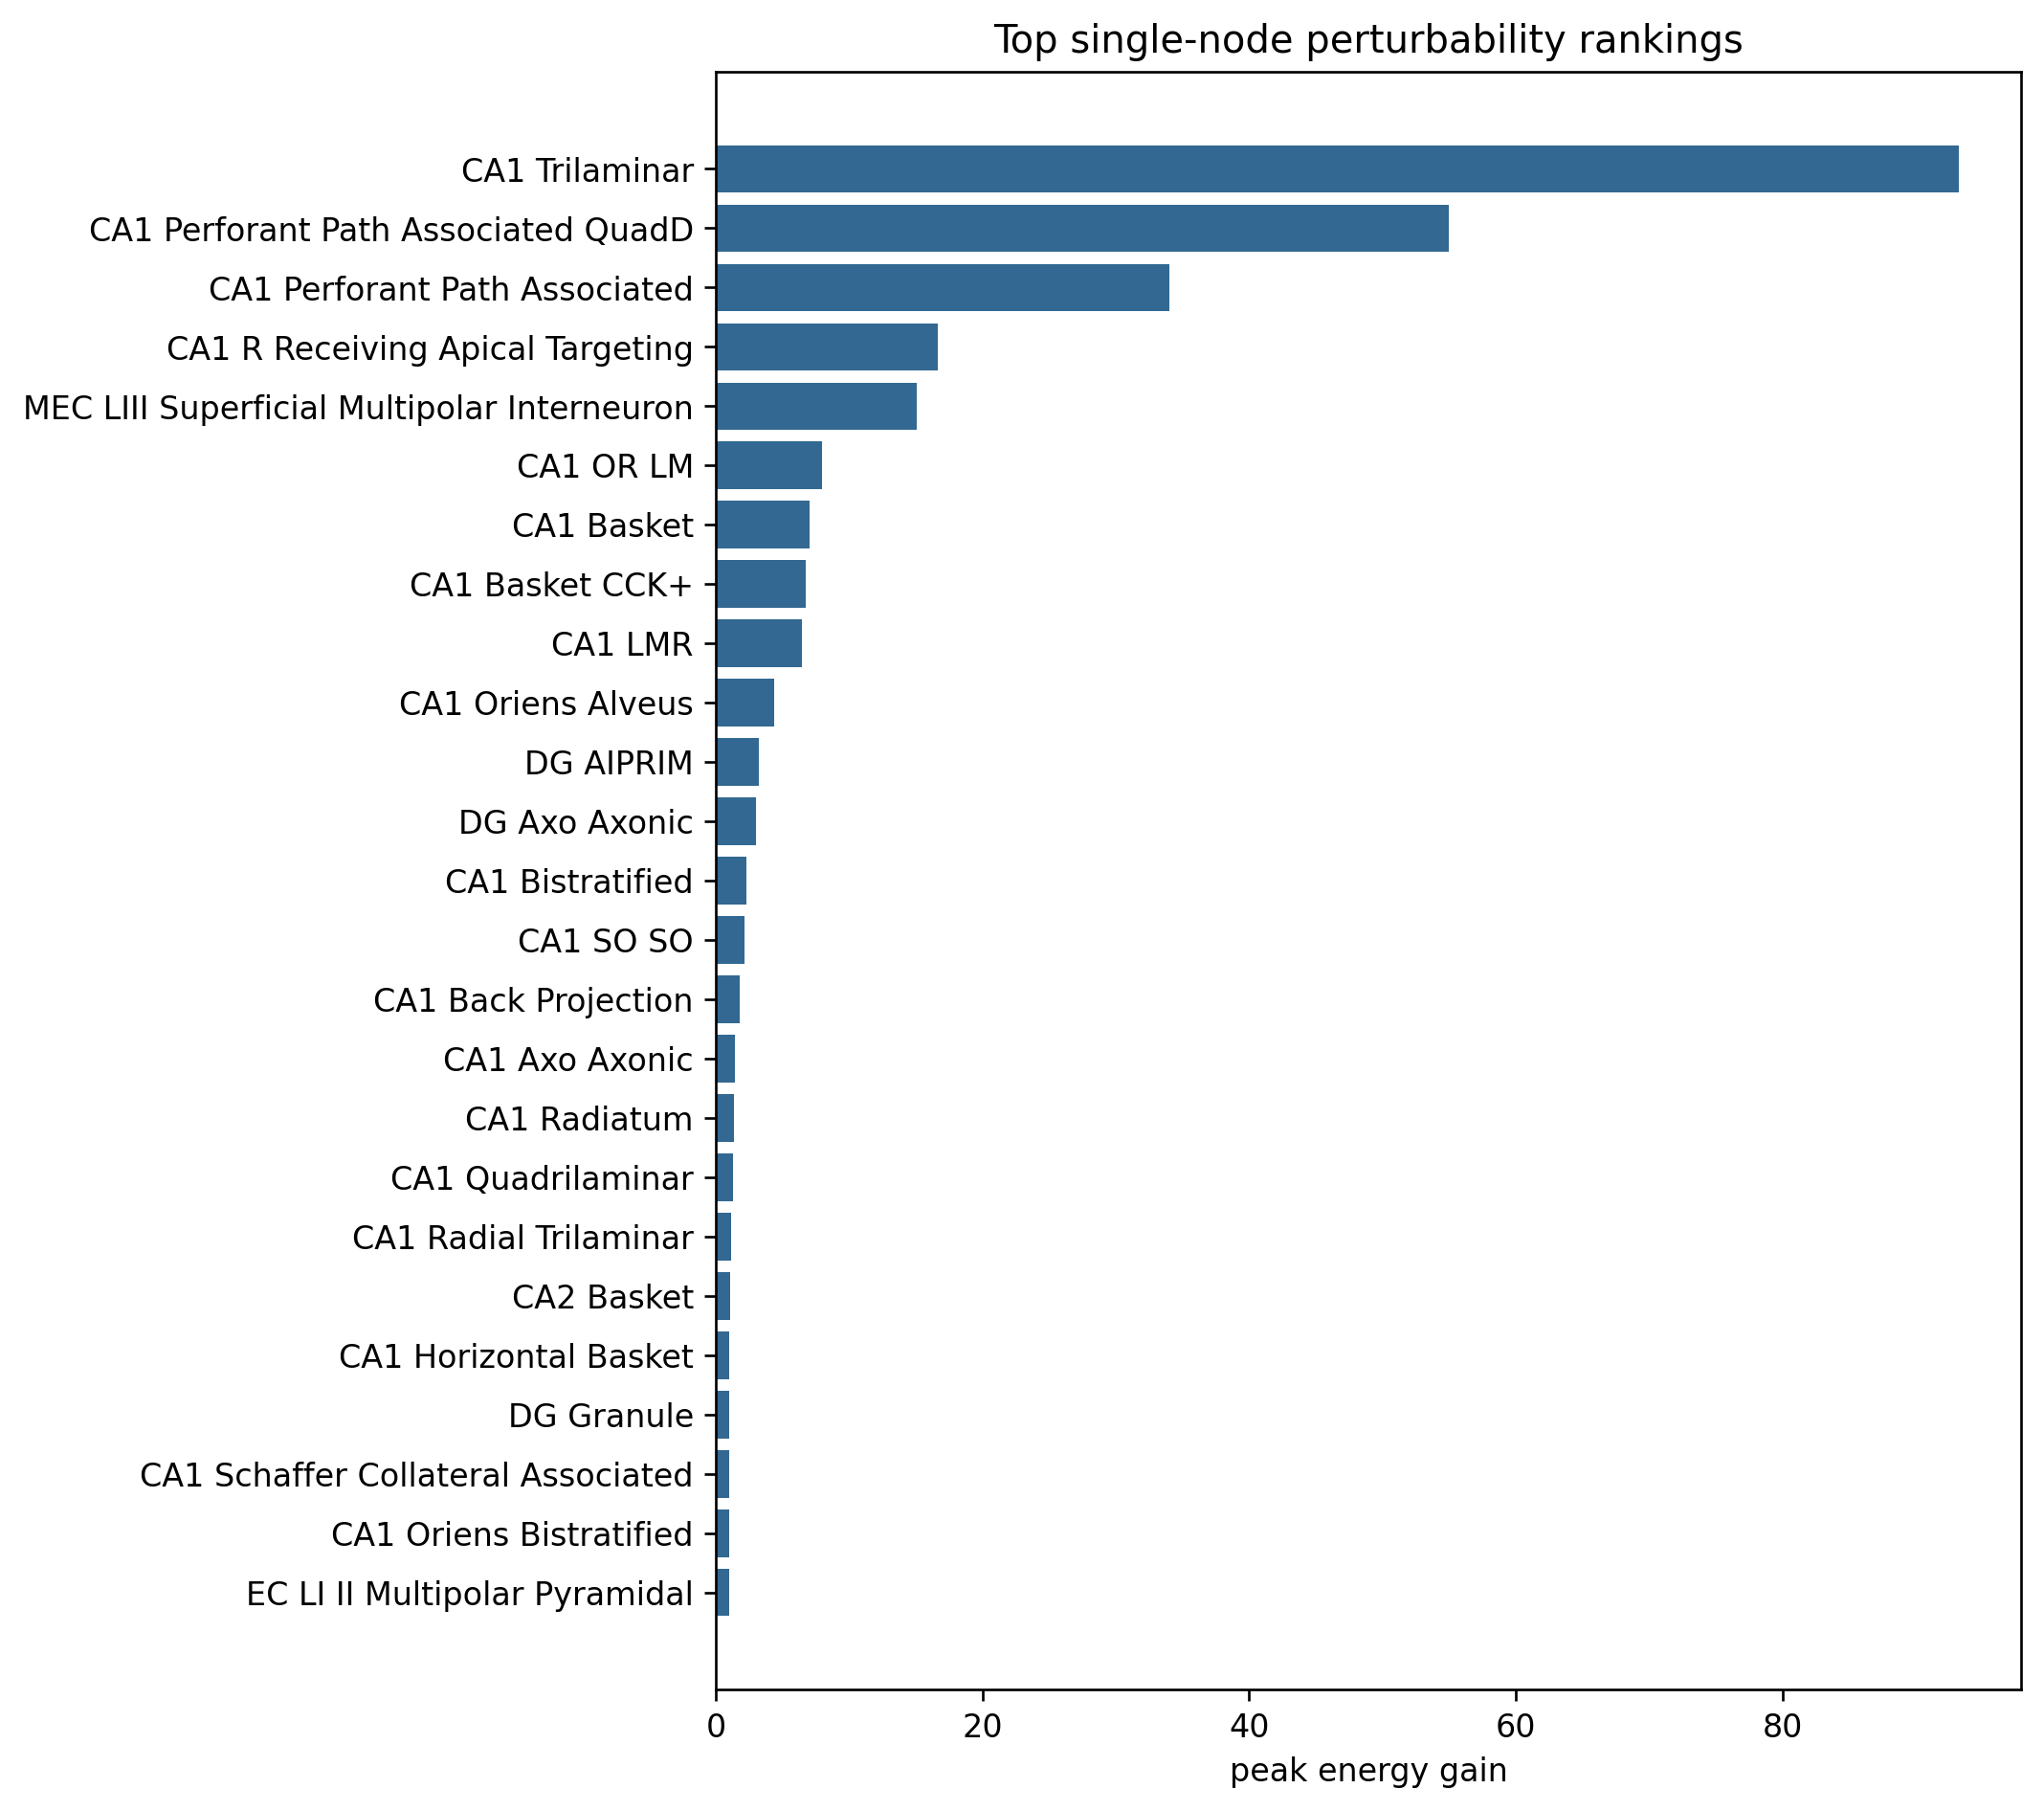

In [10]:
single_node = pd.read_csv(TABLES / "single_node_perturbability.csv")
susceptibility = pd.read_csv(TABLES / "node_susceptibility.csv")
display(single_node.head(20))
display(susceptibility.head(20))
display(Image(filename=str(FIGURES / "figure07_single_node_ranking.png")))


### What the single-node results mean

**CA1 Trilaminar** is the strongest constrained single-node initiator, with peak energy gain 93.3 and integrated energy 189.6. This differs from the leading component of the unconstrained optimal vector, confirming that a single-node input cannot reproduce the fully coordinated optimal perturbation.

The susceptibility table answers the reverse question: which targets accumulate the largest maximum received amplitudes across sources. A node may be highly susceptible without being a strong initiator, again reflecting directional flow.


## 10. Signed structure and inhibitory interpolation

### Analysis step

This step separates positive and negative weights and gradually restores the negative component.

$$A^+_{ij}=\max(A_{ij},0),\qquad A^-_{ij}=\min(A_{ij},0),$$
$$A(\beta)=A^++\beta A^-,\qquad 0\le\beta\le1.$$

### Terms

- **Positive component** $A^+$: all negative entries set to zero.
- **Negative component** $A^-$: all positive entries set to zero.
- **Inhibitory-strength parameter** $\beta$: 0 is positive-only; 1 restores the empirical signed matrix.
- Each component is spectral-norm normalized for the component comparison, and gain is evaluated at 90% of that component's own stability threshold. This compares shape at matched relative stability, not identical raw coupling.


In [11]:
signed_components = pd.read_csv(TABLES / "signed_component_comparison.csv")
beta_scan = pd.read_csv(TABLES / "signed_inhibition_interpolation.csv")
display(signed_components)
display(beta_scan)


,matrix,frobenius_norm,spectral_norm,spectral_radius,spectral_abscissa,numerical_abscissa,reactivity_gap,asymmetry_index,commutator_index,henrici_departure,henrici_index,eigenvector_condition,diagonalization_warning,alpha_A,omega_A,g_react,g_stab,reactive_to_stable_ratio,stable_reactive_width,Gmax_at_90pct_stability
0,positive,1.267966,1.0,0.016261,0.016261,0.502790,0.486529,1.414048,0.985384,1.267798,0.999867,1.168178e+06,no,0.016261,0.502790,1.988901,61.495233,0.032342,59.506332,620.197873
1,negative,1.832501,1.0,0.771936,0.026555,0.257959,0.231404,1.087688,0.485782,1.409006,0.768898,5.510773e+17,yes,0.026555,0.257959,3.876585,37.658360,0.102941,33.781775,13.463105
2,signed,1.267982,1.0,0.015607,0.015607,0.502379,0.486772,1.414095,0.985366,1.267825,0.999876,1.232785e+05,no,0.015607,0.502379,1.990529,64.073739,0.031066,62.083210,639.133470


,beta,spectral_abscissa,numerical_abscissa,commutator_index,henrici_index,g_react,g_stab,Gmax_at_90pct_stability
0,0.00,0.016261,0.502790,0.985384,0.999867,1.988901,61.495233,620.197873
1,0.05,0.016225,0.502770,0.985385,0.999869,1.988983,61.634780,621.501372
2,0.10,0.016188,0.502749,0.985385,0.999871,1.989064,61.773174,622.765528
3,0.15,0.016152,0.502728,0.985385,0.999873,1.989145,61.910421,623.990586
4,0.20,0.016117,0.502708,0.985385,0.999874,1.989227,62.046526,625.176804
5,0.25,0.016082,0.502687,0.985384,0.999876,1.989308,62.181494,626.324457
6,0.30,0.016047,0.502667,0.985384,0.999877,1.989390,62.315329,627.433831
7,0.35,0.016013,0.502646,0.985384,0.999878,1.989471,62.448037,628.505227
8,0.40,0.015980,0.502626,0.985383,0.999879,1.989552,62.579625,629.538957
9,0.45,0.015946,0.502605,0.985382,0.999878,1.989634,62.710099,630.535346


### What the signed-structure results mean

The positive-only matrix already has very high non-normality and gain: $G_{max}=620.2$. Restoring the empirical negative component increases the matched-relative-coupling gain only modestly to 639.1. The negative-only component yields much smaller gain (13.5).

Thus the signed inhibitory structure modulates the effect but does not create the dominant non-normal amplification. This result is conditional on the chosen normalization and relative-coupling comparison; it is not a statement that inhibition is biologically unimportant.


## 11. Directionality interpolation and empirical cutoffs

### Analysis step

This step removes directionality continuously while preserving the symmetric component:

$$A(q)=S+qK,\qquad 0\le q\le1.$$

### Terms

- $q=0$: fully symmetric matrix $S$, which is normal.
- $q=1$: the empirical directed matrix $S+K=A$.
- **Directionality cutoff** $q_c$: smallest scanned $q$ for which $G_{max}\ge1+\delta$.
- **Amplification tolerance** $\delta$: selected excess above unit gain. Multiple values are reported because no single cutoff is biologically canonical.
- Gain is evaluated at 90% of each interpolated matrix's own stability threshold, isolating shape at matched relative stability.


,q,spectral_abscissa,numerical_abscissa,commutator_index,henrici_index,g_react,g_stab,Gmax_at_90pct_stability
0,0.00,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000
1,0.05,0.955492,0.956683,0.098274,0.070611,1.045278,1.046581,1.000000
2,0.10,0.908749,0.913305,0.195090,0.140696,1.094925,1.100414,1.000000
3,0.15,0.863796,0.873632,0.289059,0.209751,1.144646,1.157681,1.000000
4,0.20,0.820415,0.837250,0.378928,0.277306,1.194387,1.218896,1.000000
5,0.25,0.778370,0.803771,0.463633,0.342943,1.244136,1.284736,1.000000
6,0.30,0.737436,0.772864,0.542327,0.406309,1.293889,1.356050,1.000000
7,0.35,0.697396,0.744244,0.614402,0.467116,1.343645,1.433905,1.000000
8,0.40,0.658041,0.717668,0.679480,0.525150,1.393402,1.519662,1.000000
9,0.45,0.619156,0.692924,0.737406,0.580263,1.443161,1.615101,1.002603


,delta,q_cutoff_grid
0,0.01,0.50
1,0.05,0.55
2,0.10,0.60
3,0.25,0.70


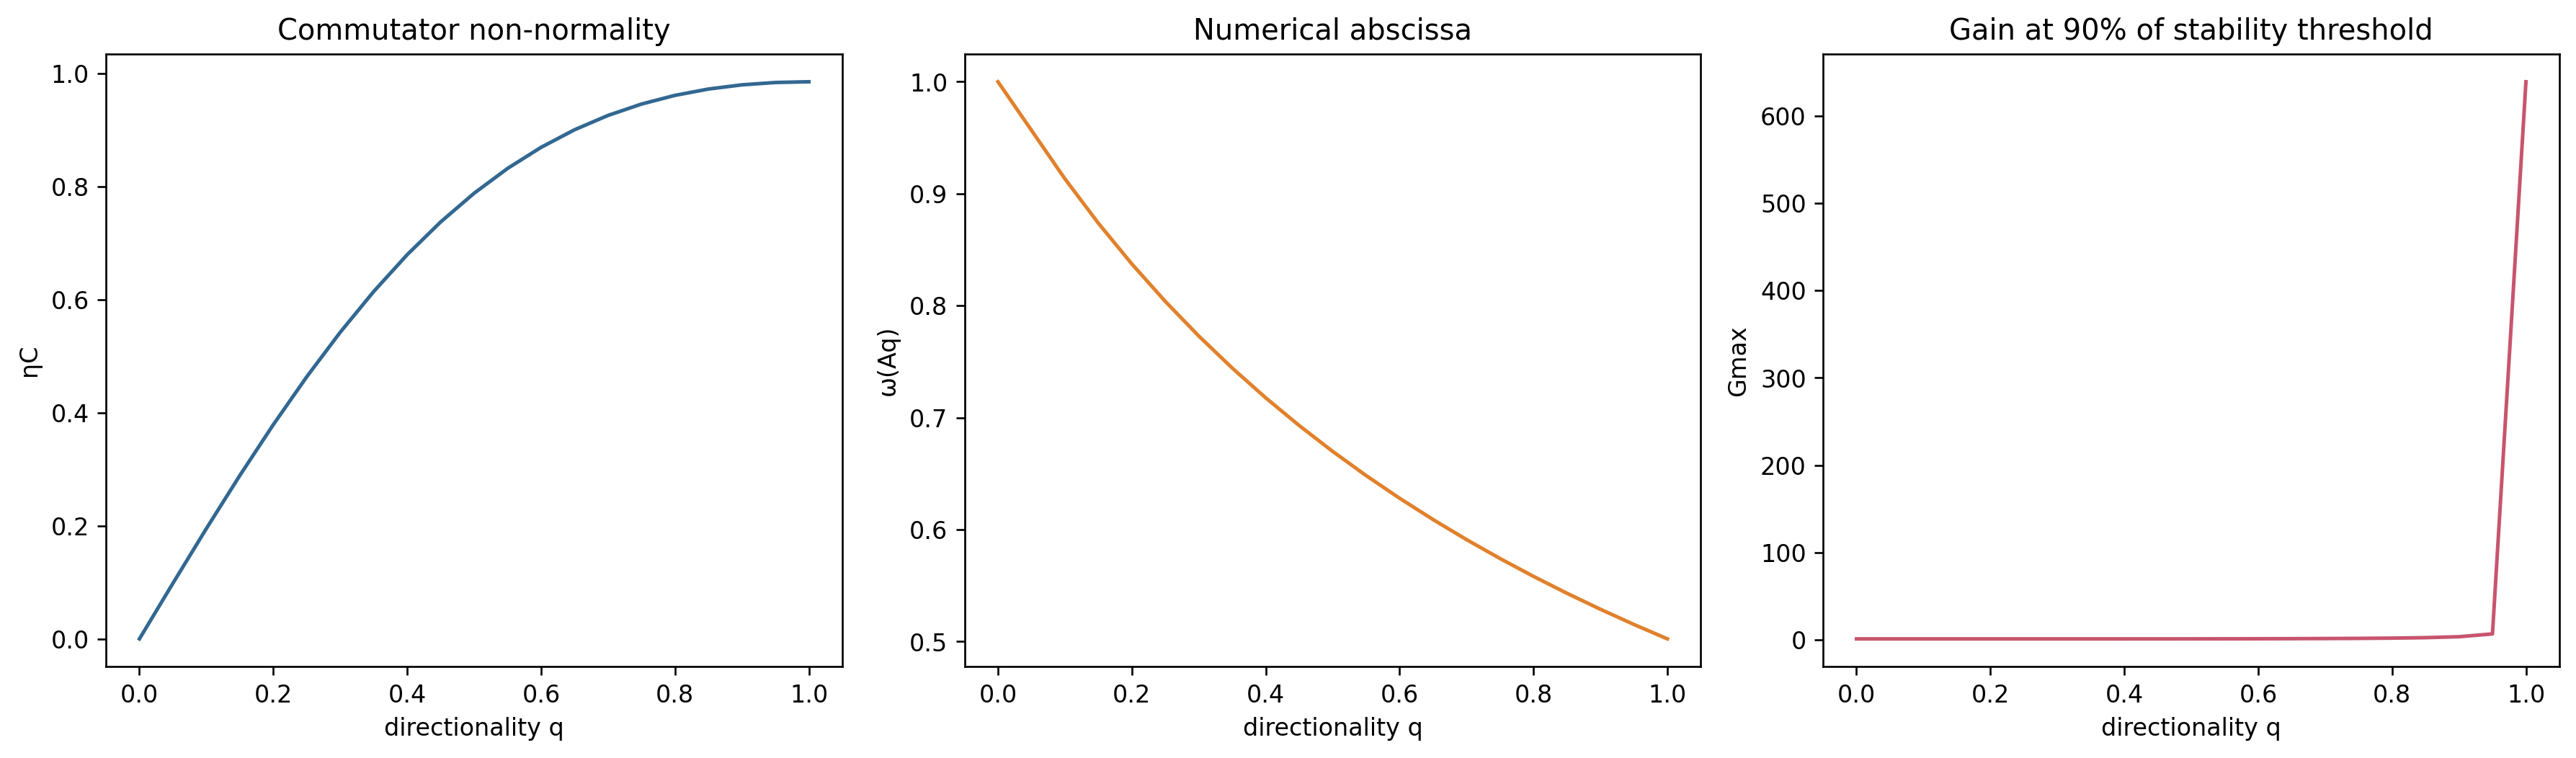

In [12]:
directionality = pd.read_csv(TABLES / "directionality_interpolation.csv")
direction_cutoffs = pd.read_csv(TABLES / "directionality_cutoffs.csv")
display(directionality)
display(direction_cutoffs)
display(Image(filename=str(FIGURES / "figure08_directionality_interpolation.png")))


### What the directionality results mean

At $q=0$, both non-normality indices are zero and $G_{max}=1$, as required for the stable symmetric normal baseline. As empirical directionality is restored, the commutator grows smoothly but large gain emerges late and sharply.

The grid cutoff is $q_c=0.50$ for a 1% gain excess and $q_c=0.70$ for a 25% excess. A substantial fraction of the empirical directional component is therefore required before amplification becomes appreciable under this criterion.


## 12. Null models and empirical significance

### Analysis step

This step asks whether the empirical metrics are unusual relative to randomized matrices that preserve selected features.

### Terms

- **Null model**: randomized control representing what would be expected if a specified structural feature were irrelevant.
- **Symmetric control**: $(A+A^T)/2$, removing directed skew.
- **Weight-shuffled null**: preserves the locations of nonzero directed edges but permutes observed signed weights across them.
- **Direction-randomized null**: randomly swaps pairwise directions while preserving the paired weights and signs as closely as possible.
- **Empirical percentile**: fraction of null values at or below the empirical value.
- **Upper-tail empirical p-value**: $(1+\#\{T_{null}\ge T_{emp}\})/(n+1)$; the +1 correction prevents zero p-values.
- **Standardized effect**: $(T_{emp}-\bar T_{null})/s_{null}$, measured in null standard deviations.
- Fifty nulls per family are used for spectral metrics; 20 per family receive the costlier gain computation.


,null_model,metric,empirical,null_mean,null_sd,standardized_effect,empirical_percentile,upper_tail_p,n
0,weight_shuffled,commutator_index,0.985366,0.610190,0.051815,7.240638,1.00,0.019608,50
1,weight_shuffled,henrici_index,0.999876,0.963474,0.041572,0.875621,1.00,0.019608,50
2,weight_shuffled,spectral_abscissa,0.015607,0.252038,0.205000,-1.153318,0.00,1.000000,50
3,weight_shuffled,numerical_abscissa,0.502379,0.537971,0.086355,-0.412158,0.36,0.647059,50
4,weight_shuffled,Gmax_at_90pct_stability,639.412493,62.185827,202.887949,2.845052,0.95,0.095238,20
5,direction_randomized,commutator_index,0.985366,0.686693,0.074190,4.025770,1.00,0.019608,50
6,direction_randomized,henrici_index,0.999876,0.932772,0.026833,2.500771,1.00,0.019608,50
7,direction_randomized,spectral_abscissa,0.015607,0.273607,0.065567,-3.934884,0.00,1.000000,50
8,direction_randomized,numerical_abscissa,0.502379,0.622217,0.040480,-2.960400,0.00,1.000000,50
9,direction_randomized,Gmax_at_90pct_stability,639.412493,10.747667,7.384170,85.136833,1.00,0.047619,20


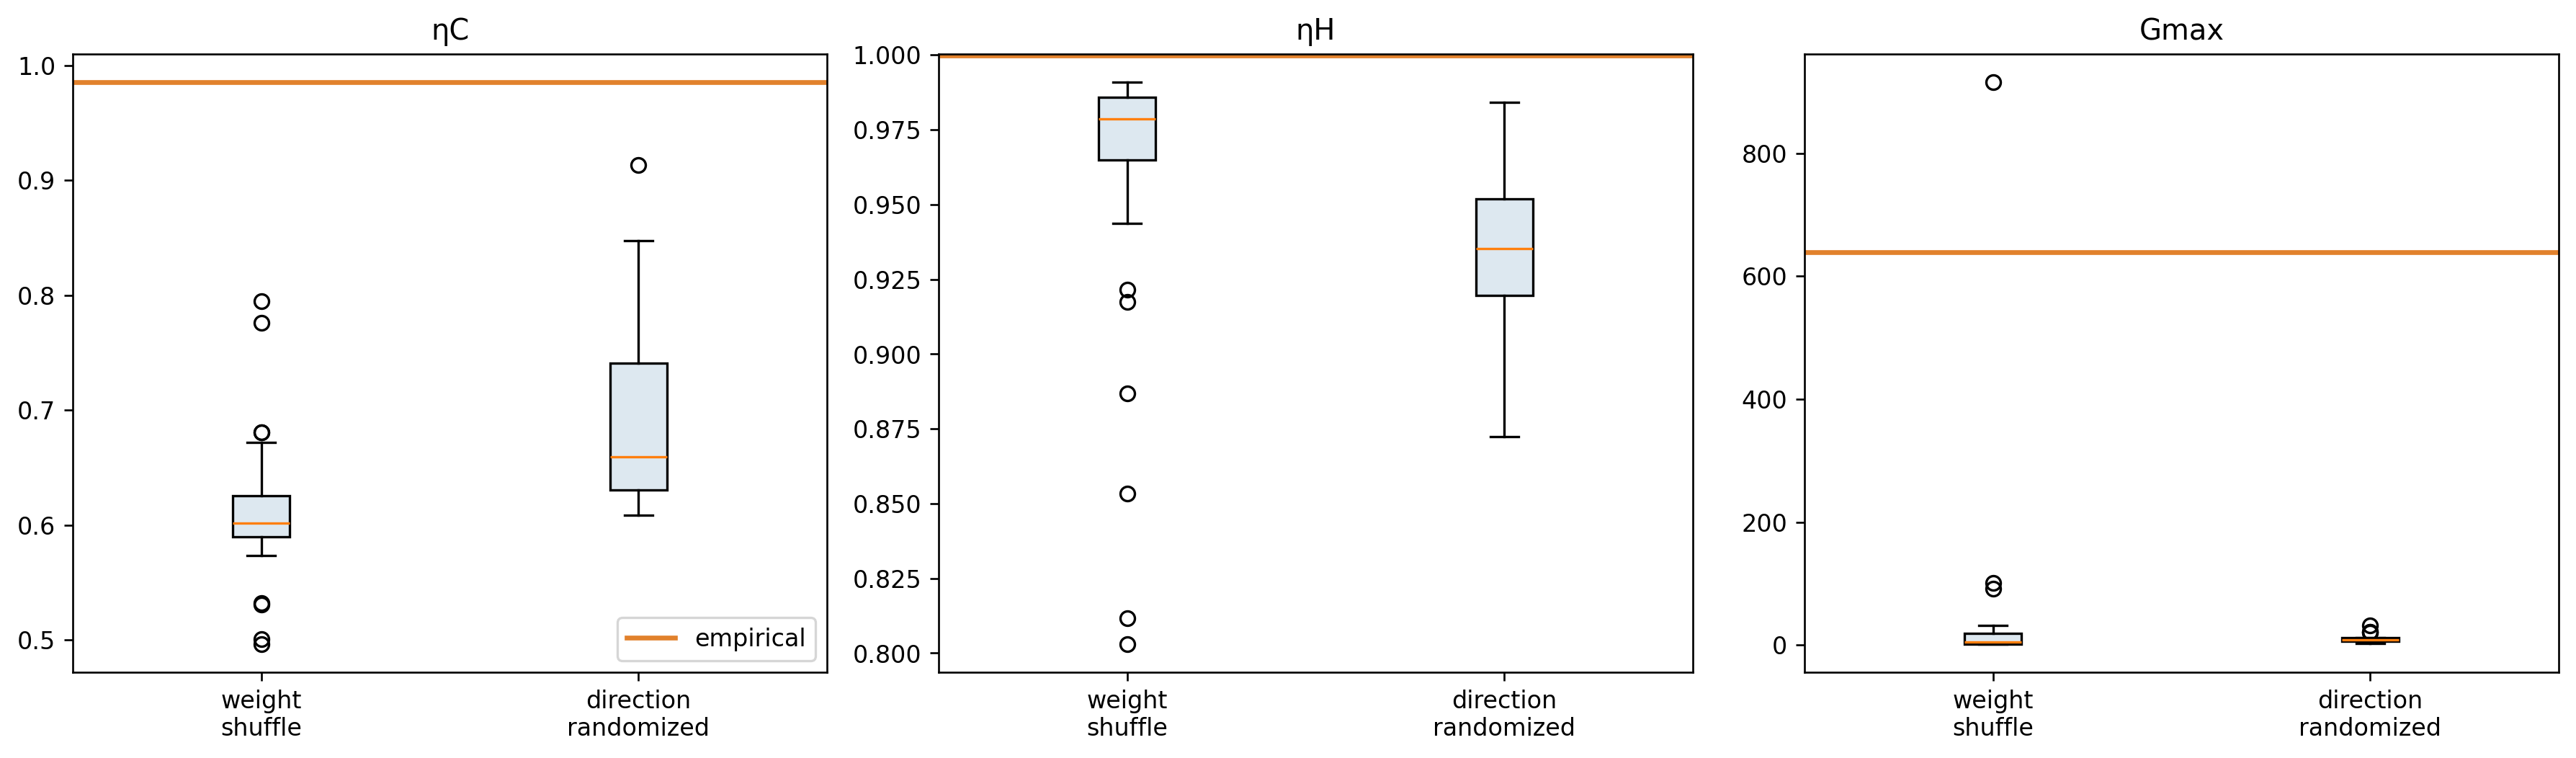

In [13]:
null_results = pd.read_csv(TABLES / "null_model_results.csv")
null_statistics = pd.read_csv(TABLES / "empirical_vs_null_statistics.csv")
display(null_statistics)
display(Image(filename=str(FIGURES / "figure09_null_distributions.png")))


### What the null-model results mean

The empirical commutator index is above all 50 weight-shuffled and all 50 direction-randomized values; the corrected upper-tail p-value is 0.0196 for both families. The empirical Henrici index is also above all sampled nulls.

Gain is above the direction-randomized controls (p=0.0476 across 20 gain nulls), but the weight-shuffled gain comparison is less decisive (p=0.0952). The evidence therefore supports unusually strong empirical non-normality and direction-dependent gain, while the exact tail probability for gain remains uncertain because only 20 costly gain nulls were evaluated. These p-values are exploratory, not publication-final.


## 13. Node lesion analysis

### Analysis step

For each node, this step removes its row and column and recomputes spectral, reactivity, and gain-related metrics.

### Terms

- **Node lesion**: removal of both the node's incoming row and outgoing column.
- **Lesion effect** $\Delta G_{max,i}=G_{max}^{(-i)}-G_{max}$: negative values mean removal reduces amplification.
- **Gain screen**: lesion gain is evaluated at five times around the empirical $t_*$ rather than fully re-optimized for all 85 lesions.
- **Exact lesion thresholds**: lesion $\alpha$, $\omega$, $g_{react}$, and $g_{stab}$ are recomputed directly and are not screened approximations.
- A node can have a strong lesion effect without being the strongest input component because removal changes the entire propagation operator.


,node,spectral_abscissa_A_lesion,numerical_abscissa_A_lesion,g_react_lesion,g_stab_lesion,Gmax_screen_lesion,delta_Gmax_screen
0,CA3c Pyramidal,0.015579,0.387305,2.581944,64.188315,96.519850,-81.125071
1,CA1 Perforant Path Associated QuadD,0.015607,0.424935,2.353300,64.073753,131.496589,-46.148331
2,CA3 Pyramidal,0.015582,0.476901,2.096872,64.177441,144.483640,-33.161281
3,CA1 Trilaminar,0.015609,0.478729,2.088865,64.067088,148.443833,-29.201087
4,CA1 Perforant Path Associated,0.015608,0.458964,2.178821,64.070991,152.381870,-25.263051
5,CA1 R Receiving Apical Targeting,0.015607,0.480510,2.081121,64.073172,164.124567,-13.520353
6,CA2 Pyramidal,0.015584,0.499497,2.002013,64.168696,164.404044,-13.240877
7,CA1 Pyramidal,0.015548,0.500747,1.997017,64.317369,167.032373,-10.612547
8,CA1 OR LM,0.015607,0.491528,2.034472,64.073519,170.771231,-6.873689
9,CA1 Basket,0.015608,0.492623,2.029951,64.068214,172.165057,-5.479863


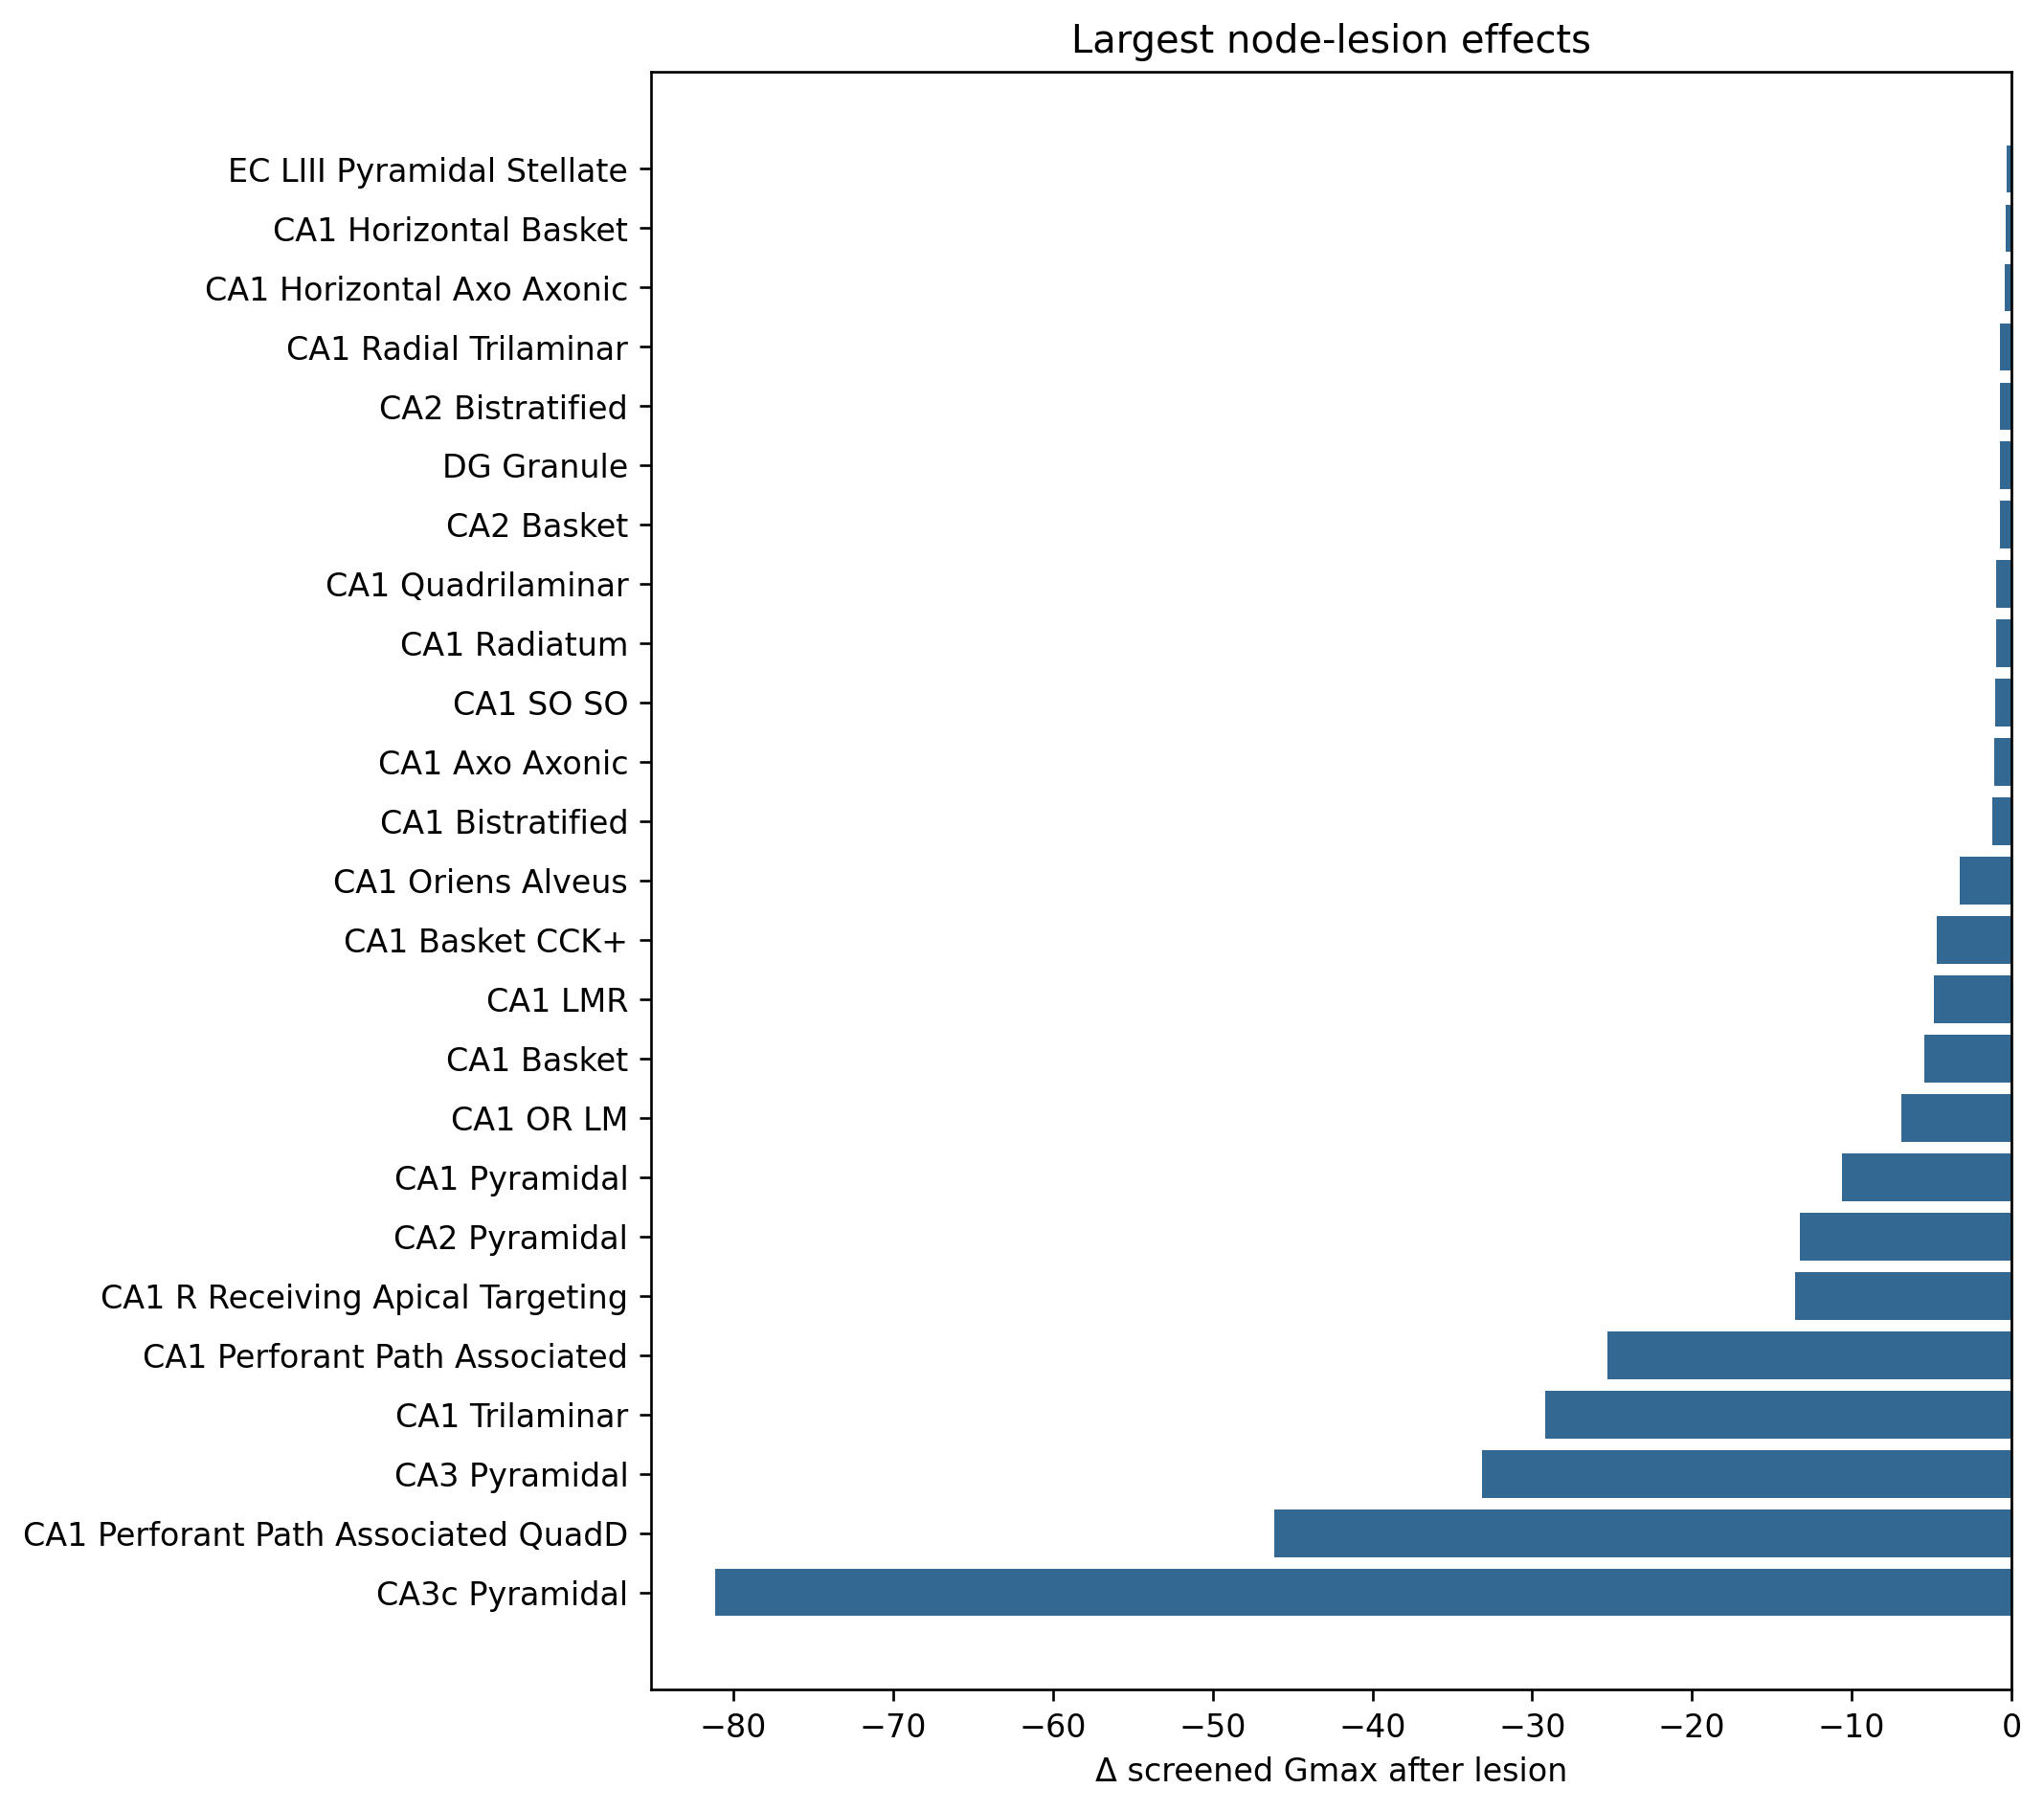

In [14]:
lesions = pd.read_csv(TABLES / "node_lesion_effects.csv")
display(lesions.head(25))
display(Image(filename=str(FIGURES / "figure10_node_lesions.png")))


### What the lesion results mean

Removing **CA3c Pyramidal** produces the largest screened reduction in gain ($\Delta G\approx-81.1$), followed by **CA1 Perforant Path Associated QuadD**. The leading lesion is the dominant response receiver, not the leading single-node initiator.

This identifies nodes structurally important to the amplification pathway, but the gain values are screening estimates. The top candidates should be fully re-optimized in time before making inferential or experimental-prioritization claims.


## 14. Edge perturbation and local sensitivity

### Analysis step

This step estimates how small changes in each nonzero edge affect stability, reactivity, and peak gain, prioritizing the most consequential edges.

### Terms

- **Edge perturbation**: $A_{ij}\to(1+\epsilon)A_{ij}$ or deletion $A_{ij}\to0$.
- **Derivative** $d\alpha/dA_{ij}$ or $d\omega/dA_{ij}$: first-order local change per unit edge-weight change.
- **Elasticity** $A_{ij}\,dT/dA_{ij}$: first-order change in metric $T$ for a fractional edge change.
- **Frechet derivative of the matrix exponential**: linear response of $e^{Jt}$ to a matrix perturbation; used for gain sensitivity.
- **Local sensitivity** does not guarantee the same effect for a large perturbation or full edge deletion.
- Gain Frechet derivatives are evaluated for the top 40 edges screened by spectral/reactivity sensitivity.


In [15]:
edge_sensitivity = pd.read_csv(TABLES / "edge_sensitivity.csv")
display(edge_sensitivity[["source", "target", "weight", "elasticity_alpha", "elasticity_omega", "dG_dAij", "elasticity_G"]].head(25))


,source,target,weight,elasticity_alpha,elasticity_omega,dG_dAij,elasticity_G
0,CA1 Perforant Path Associated QuadD,CA3c Pyramidal,0.563269,1.418917e-09,1.400013e-01,150.594372,84.825195
1,CA1 Perforant Path Associated,CA3c Pyramidal,0.460669,-2.885423e-07,8.734844e-02,110.775779,51.031004
2,CA1 Trilaminar,CA3 Pyramidal,0.730783,-1.099548e-06,6.724222e-02,94.017701,68.706499
3,CA1 R Receiving Apical Targeting,CA3c Pyramidal,0.312495,-7.158396e-08,4.121654e-02,79.331298,24.790640
4,CA1 OR LM,CA3c Pyramidal,0.212645,-2.737638e-08,1.966992e-02,56.137041,11.937244
5,CA1 Basket,CA3c Pyramidal,0.209893,-7.933153e-07,1.844558e-02,49.853205,10.463837
6,CA1 Trilaminar,CA3c Pyramidal,0.098761,-6.933432e-08,1.837191e-02,144.645990,14.285428
7,CA1 Basket CCK+,CA3c Pyramidal,0.207793,-1.276095e-06,1.760378e-02,46.040737,9.566954
8,CA1 LMR,CA3c Pyramidal,0.204244,-1.862672e-08,1.695029e-02,47.217891,9.643987
9,CA1 Perforant Path Associated QuadD,CA3 Pyramidal,0.117763,6.357884e-10,1.447803e-02,97.892391,11.528055


### What the edge-sensitivity results mean

The leading locally sensitive edge is **CA1 Perforant Path Associated QuadD → CA3c Pyramidal**. Its gain elasticity is 84.8, and it also has the largest reactivity elasticity among the prioritized edges. Several other top-ranked edges converge on the same CA3c Pyramidal target.

The ranking identifies high-value candidates for explicit deletion or bidirectional perturbation tests. Because these are derivatives around the empirical weight, they should not be interpreted as exact effects of removing an edge entirely.


## 15. Pseudospectral analysis

### Analysis step

This step evaluates how close the stable operator is to having eigenvalues elsewhere in the complex plane under small perturbations.

### Terms

- **Resolvent** $(zI-J)^{-1}$: frequency-domain response at complex point $z$.
- **Resolvent norm** $\|(zI-J)^{-1}\|_2$: large values mean $zI-J$ is nearly singular.
- **$\epsilon$-pseudospectrum** $\Lambda_\epsilon(J)=\{z:\|(zI-J)^{-1}\|_2>1/\epsilon\}$: points that can behave like eigenvalues after perturbations of approximate size $\epsilon$.
- **Pseudospectral bulging**: contours extending far from the eigenvalues, characteristic of non-normal sensitivity.
- **Right half-plane** $\operatorname{Re}z>0$: the unstable side of the continuous-time complex plane.
- The displayed result is a finite grid approximation, not a certified contour boundary.


,quantity,value
0,max resolvent sampled in Re(z)>0,36.444108
1,smallest epsilon implied by sampled grid,0.027439


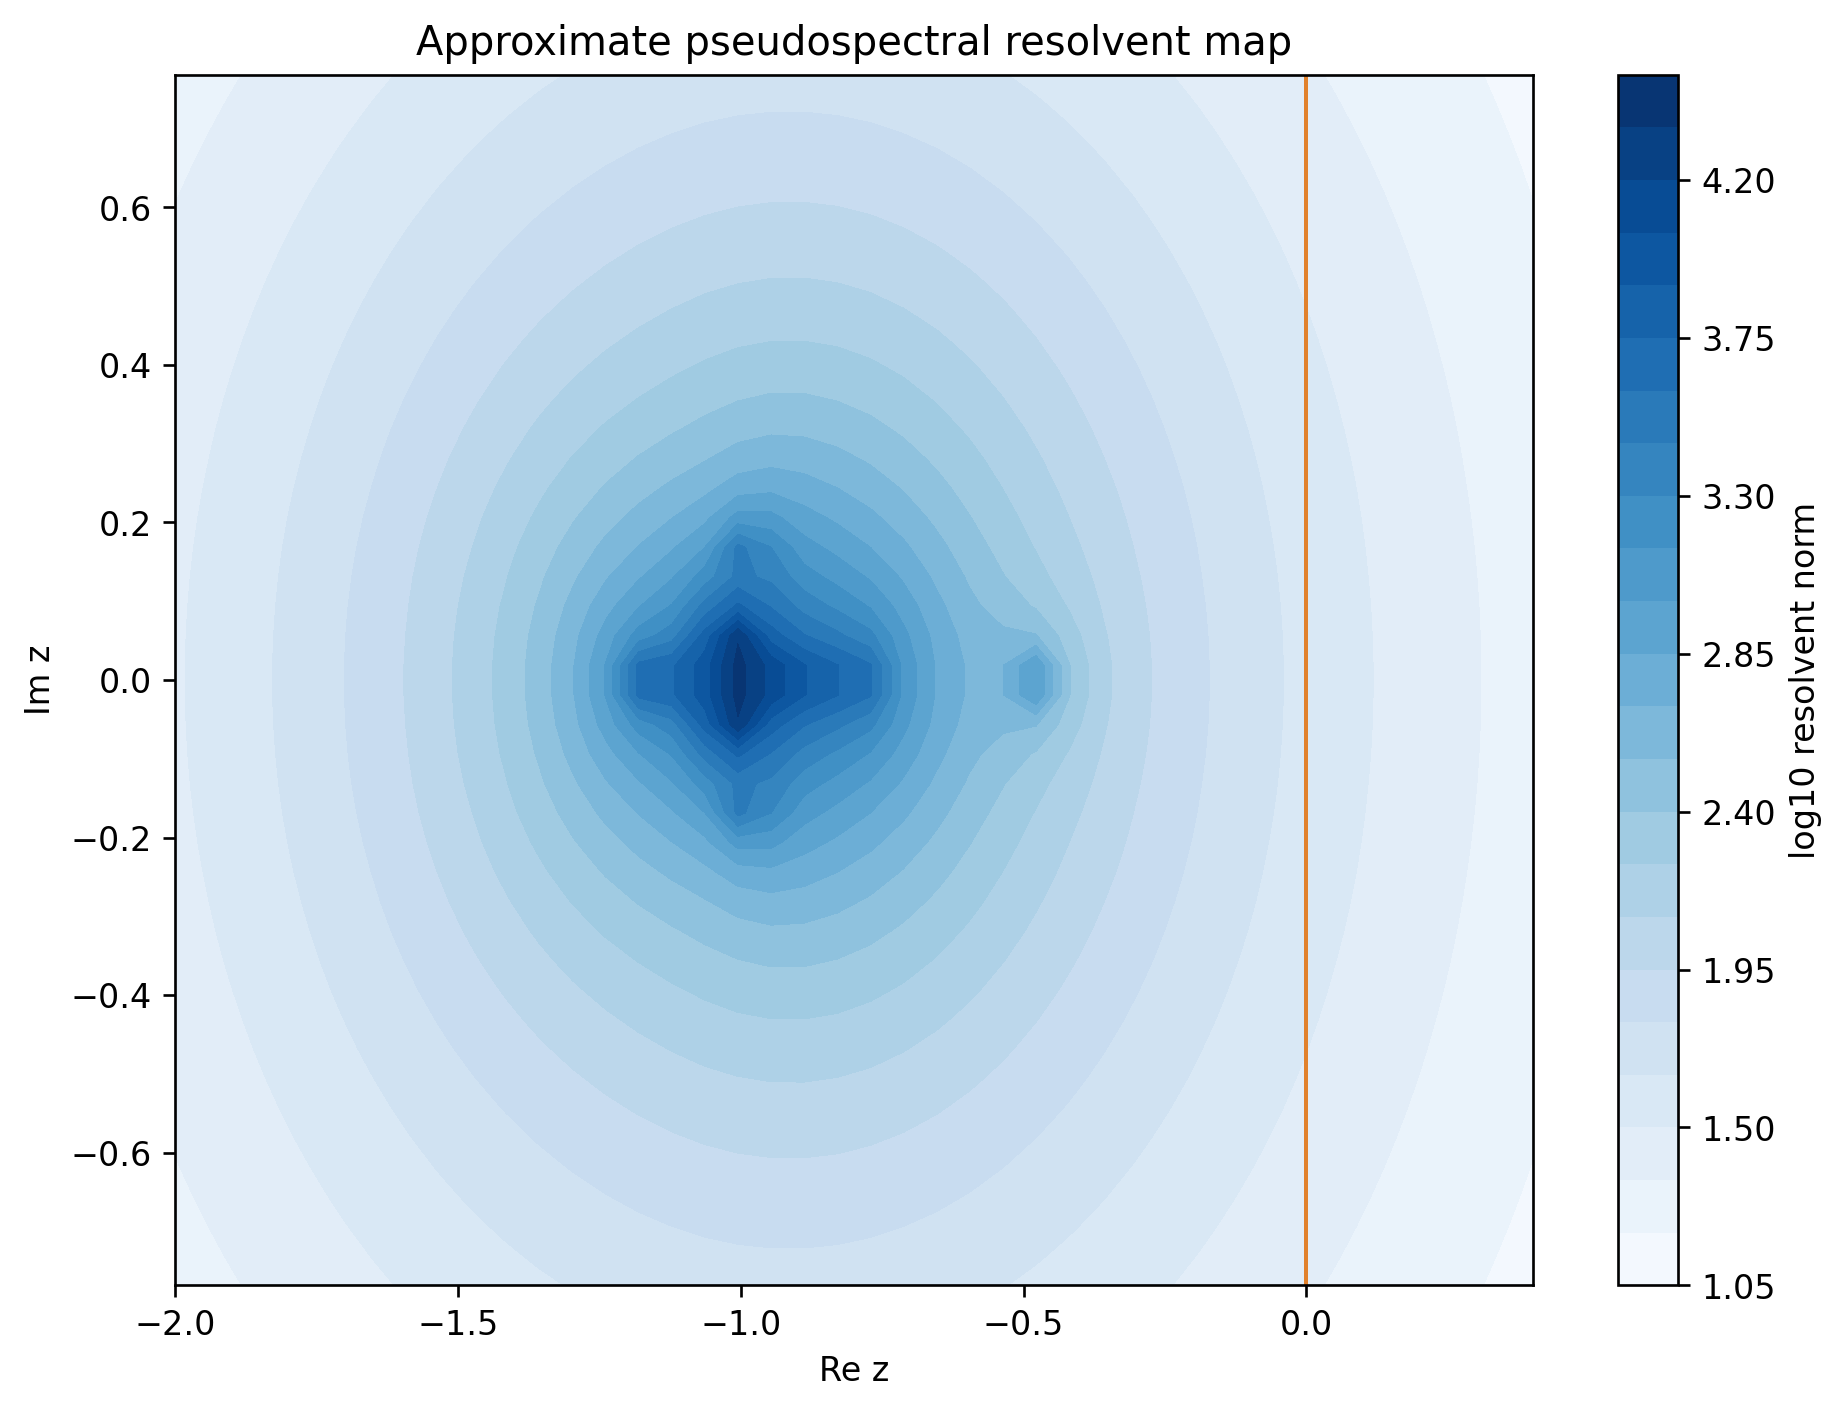

In [16]:
pseudo = np.load(OUT / "pseudospectrum_grid.npz")
right_mask = pseudo["real"] > 0
max_right_resolvent = 10 ** pseudo["log10_resolvent"][:, right_mask].max()
epsilon_grid = 1 / max_right_resolvent
display(pd.DataFrame({"quantity": ["max resolvent sampled in Re(z)>0", "smallest epsilon implied by sampled grid"],
                      "value": [max_right_resolvent, epsilon_grid]}))
display(Image(filename=str(FIGURES / "figure11_pseudospectrum.png")))


### What the pseudospectrum means

Although all eigenvalues of the selected $J$ lie in the stable half-plane, the sampled pseudospectrum reaches $\operatorname{Re}z>0$ at approximately $\epsilon=0.027$. This indicates sensitivity to structured operator perturbations and is consistent with the large transient gain.

The value depends on the finite grid extent and resolution. It should be treated as a diagnostic scale, not an exact robust-stability radius.


## 16. Stochastic perturbations and covariance

### Analysis step

This step replaces a single deterministic impulse with continuous white-noise forcing:

$$dx=Jx\,dt+B\,dW_t,$$

using $B=I$ and a coupling stable for both empirical and symmetrized networks.

### Terms

- **Wiener process** $W_t$: idealized continuous-time white-noise source.
- **Noise matrix** $B$: maps independent noise sources into nodes; $B=I$ gives equal independent forcing.
- **Stationary covariance** $C$: long-run covariance of $x$ when $J$ is stable.
- **Lyapunov equation** $JC+CJ^T+BB^T=0$: equation solved for $C$.
- **Total stationary variance** $\operatorname{tr}(C)$: sum of node variances.
- **Nodewise variance** $C_{ii}$: stationary variance at node $i$.
- **Covariance mode**: eigenvector of $C$; its eigenvalue is variance carried by that collective pattern.
- Peak deterministic gain and stationary variance need not rank networks or nodes identically.


In [17]:
node_variance = pd.read_csv(TABLES / "stochastic_node_variance.csv")
covariance_modes = pd.read_csv(TABLES / "stochastic_covariance_modes.csv")
display(pd.DataFrame({
    "network": ["empirical", "symmetrized"],
    "common coupling": [summary["stochastic_comparison_coupling"]] * 2,
    "total stationary variance": [summary["total_stationary_variance"], summary["symmetrized_total_stationary_variance"]],
}))
display(node_variance.head(15))
display(covariance_modes)


,network,common coupling,total stationary variance
0,empirical,1.791476,43.814605
1,symmetrized,1.791476,47.531984


,node,stationary_variance
0,CA3c Pyramidal,1.224131
1,CA3 Pyramidal,0.979098
2,EC LI II Multipolar Pyramidal,0.560807
3,DG Granule,0.530732
4,CA2 Pyramidal,0.509092
5,CA1 Pyramidal,0.503921
6,EC LIII Pyramidal Stellate,0.502601
7,EC LI II Pyramidal Fan,0.502162
8,EC LII III Pyramidal Tripolar,0.501877
9,DG Mossy,0.501146


,mode,eigenvalue,variance_fraction
0,1,1.516164,0.034604
1,2,1.072880,0.024487
2,3,0.650492,0.014846
3,4,0.610363,0.013931
4,5,0.516292,0.011784
5,6,0.513427,0.011718
6,7,0.511234,0.011668
7,8,0.508948,0.011616
8,9,0.506636,0.011563
9,10,0.502976,0.011480


### What the stochastic results mean

At the largest tested coupling stable for both systems, $g=1.791$, total stationary variance is 43.81 for the empirical network and 47.53 for the symmetrized network. The empirical value is therefore slightly smaller at this low common coupling.

This does not contradict the deterministic gain result: the empirical network's striking amplification occurs much deeper in its unusually broad stable-reactive interval, at couplings where the symmetrized network is already unstable and has no stationary covariance. Comparisons require a domain where both Lyapunov solutions are physically meaningful.


## 17. Robustness to preprocessing and extreme weights

### Analysis step

This step repeats key metrics after controlled modifications to determine which conclusions are structural and which depend on a few entries.

### Terms

- **Remove diagonal**: set self-connections $A_{ii}$ to zero.
- **Remove top $p\%$ edges**: set the largest $p\%$ of nonzero absolute weights to zero.
- **Winsorization/clipping**: cap weights at a selected percentile while preserving their signs and edge locations.
- **Random weight noise**: multiply nonzero weights by small random factors.
- **Robust conclusion**: remains qualitatively similar across plausible perturbations.
- Every variant is spectral-norm normalized, and gain is measured at 90% of that variant's own stability threshold.


In [18]:
robustness = pd.read_csv(TABLES / "robustness_analysis.csv")
display(robustness)


,variant,commutator_index,henrici_index,spectral_abscissa,numerical_abscissa,alpha_A,omega_A,g_react,g_stab,reactive_to_stable_ratio,stable_reactive_width,Gmax_at_90pct_stability
0,raw,0.985366,0.999876,0.015607,0.502379,0.015607,0.502379,1.990529,64.073739,0.031066,62.083210,639.412493
1,no_diagonal,0.985446,0.999908,0.008834,0.502084,0.008834,0.502084,1.991697,113.194400,0.017595,111.202703,2574.732954
2,remove_top_1pct_edges,0.798103,0.997834,0.071348,0.516530,0.071348,0.516530,1.935994,14.015811,0.138129,12.079816,45.519386
3,remove_top_5pct_edges,0.561318,0.981217,0.275169,0.585398,0.275169,0.585398,1.708240,3.634126,0.470055,1.925886,3.514014
4,remove_top_10pct_edges,0.494813,0.952313,0.314389,0.637532,0.314389,0.637532,1.568549,3.180775,0.493134,1.612226,5.722789
5,winsor_95pct,0.804272,0.991043,0.149420,0.550964,0.149420,0.550964,1.815001,6.692535,0.271198,4.877535,12.110690
6,winsor_99pct,0.964719,0.999196,0.039163,0.510362,0.039163,0.510362,1.959394,25.534547,0.076735,23.575153,131.413547
7,weight_noise_1pct,0.984876,0.999876,0.015583,0.502396,0.015583,0.502396,1.990463,64.171137,0.031018,62.180674,644.072199
8,weight_noise_5pct,0.995756,0.999885,0.014833,0.501928,0.014833,0.501928,1.992319,67.415546,0.029553,65.423227,676.468826


### What the robustness results mean

Small 1% and 5% random weight noise leaves the qualitative high-gain result intact. Removing the diagonal also leaves extreme non-normality and can increase matched-relative-coupling gain.

The conclusion is not robust to removing the extreme edge tail: gain falls from 639.4 in the primary matrix to 45.5 after removing the largest 1% of edges and 3.5 after removing the largest 5%. Winsorization produces the same qualitative warning. The network's strong amplification is therefore structurally real in the supplied matrix but heavily concentrated in its largest weights; validating those weights is biologically important.


## 18. Nonlinear extension

### Analysis step

The linear calculations extend locally to a justified nonlinear model, for example

$$\tau_i\dot x_i=-x_i+\phi\!\left(g\sum_jA_{ij}x_j+I_i\right).$$

At an equilibrium $x^*$, compute the **Jacobian**

$$J=DF(x^*),$$

the matrix of partial derivatives of the nonlinear vector field $F$ evaluated at that equilibrium.

### Terms

- **Activation function** $\phi$: nonlinear input-output function.
- **Time constant** $\tau_i$: intrinsic response timescale of node $i$.
- **Baseline input** $I_i$: external drive.
- **Equilibrium** $x^*$: state satisfying $F(x^*)=0$.
- **Jacobian** $DF(x^*)$: best linear approximation near $x^*$.
- **State-dependent reactivity**: $\omega(J)$ and transient gain change with the equilibrium because derivatives of $\phi$ depend on state.
- A nonlinear simulation is not justified until $\phi$, $\tau_i$, $I_i$, parameter values, and the relevant equilibrium are specified.


In [19]:
nonlinear_extension = pd.DataFrame({
    "linear diagnostic": ["spectral abscissa", "numerical abscissa", "finite-time gain", "optimal perturbation"],
    "nonlinear local calculation": ["alpha(DF(x*))", "omega(DF(x*))", "||exp(DF(x*) t)||_2^2", "leading right singular vector of exp(DF(x*) t*)"],
    "interpretation": ["local asymptotic stability", "local instantaneous reactivity", "local finite-time amplification", "most amplified small perturbation near x*"],
})
display(nonlinear_extension)


,linear diagnostic,nonlinear local calculation,interpretation
0,spectral abscissa,alpha(DF(x*)),local asymptotic stability
1,numerical abscissa,omega(DF(x*)),local instantaneous reactivity
2,finite-time gain,||exp(DF(x*) t)||_2^2,local finite-time amplification
3,optimal perturbation,leading right singular vector of exp(DF(x*) t*),most amplified small perturbation near x*


### What the nonlinear extension means

The entire linear toolkit applies locally after replacing the structural matrix by the equilibrium Jacobian. Structural non-normality can then be amplified, suppressed, or redirected by state-dependent gains $\phi'$. Consequently, a network may be reactive around one equilibrium and non-reactive around another.

The present analysis does not select a nonlinear model because the required activation functions, time constants, inputs, and operating state were not supplied. Inventing them would add assumptions that could dominate the result.


## 19. Compact scientific synthesis

### Analysis step

This final computation gathers the central numerical findings in one table. Each row answers a distinct scientific question; no row should be substituted for another.


In [20]:
synthesis = pd.DataFrame([
    ("How non-normal?", f"eta_C={non_normality.loc[non_normality.matrix == 'raw', 'commutator_index'].iloc[0]:.3f}; omega/alpha={summary['omega_A2']/summary['alpha_A2']:.1f}"),
    ("Stable-reactive interval", f"g_react={summary['g_react']:.3f}; g_stab={summary['g_stab']:.3f}"),
    ("Mid-interval amplification", f"Gmax={summary['Gmax_operating']:.1f} at t*={summary['t_star_operating']:.3f}"),
    ("Leading optimal initiator", summary["top_initiator"]),
    ("Leading receiver", summary["top_receiver"]),
    ("Leading single-node initiator", summary["top_single_node"]),
    ("Strongest screened lesion", summary["strongest_gain_reducing_lesion_screen"]),
    ("Leading local edge sensitivity", summary["top_edge_by_local_spectral_or_reactivity_sensitivity"]),
], columns=["question", "result"])
display(synthesis)


,question,result
0,How non-normal?,eta_C=0.985; omega/alpha=32.2
1,Stable-reactive interval,g_react=1.991; g_stab=64.074
2,Mid-interval amplification,Gmax=177.6 at t*=1.104
3,Leading optimal initiator,CA1 Perforant Path Associated QuadD
4,Leading receiver,CA3c Pyramidal
5,Leading single-node initiator,CA1 Trilaminar
6,Strongest screened lesion,CA3c Pyramidal
7,Leading local edge sensitivity,CA1 Perforant Path Associated QuadD -> CA3c Py...


### What the complete analysis means

The supplied connectomic matrix is not merely asymmetric: it is strongly non-normal and supports a broad range of stable couplings with substantial transient amplification. Directionality is essential, while the negative component modestly modifies rather than creates the dominant effect. Initiators, receivers, susceptible nodes, and lesion-control nodes are distinct roles.

The empirical commutator is more extreme than the sampled null controls, and the pseudospectrum supports structural sensitivity. However, the largest weights dominate the magnitude, gain-null replication is limited, lesion gain is screened, and the raw weights lack calibrated dynamical units. The strongest defensible conclusion is therefore structural: **the supplied directed weight pattern has exceptional capacity for stable transient amplification under explicit normalized linear dynamics**. Biological meaning requires independent validation of the extreme weights and a justified operating coupling.


## Takeaways and next checks

1. Validate the largest-weight pathways, because they control much of the amplification.
2. Increase gain-null replication to at least 100–500 per null family for publication-grade tail estimates.
3. Fully re-optimize gain for the leading lesion candidates and explicitly delete the top edge candidates.
4. Add a signed degree- or strength-preserving rewiring null if a well-mixed sampling procedure can be demonstrated.
5. Specify physiological time constants, inputs, activation functions, and an equilibrium before nonlinear simulation.

### Interpretation guardrail

Mathematical sensitivity identifies where a model is most responsive. It does **not** by itself demonstrate biological causation, experimental controllability, or functional importance.
